In [ ]:
# ============================================================
# CELL 1 — SETUP, EXTRACT CICIDS2017, EXTRACT MODELS
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os, zipfile, shutil, glob, gc, pickle, joblib, warnings
import numpy as np
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/CICIDS2018"

# CICIDS2017 ZIP kamu
CICIDS2017_ZIP = os.path.join(BASE_DIR, "MachineLearningCSV.zip")

# ZIP model kamu
ZIP_AE   = os.path.join(BASE_DIR, "model_AE_MLP (1).zip")
ZIP_MLP  = os.path.join(BASE_DIR, "model_MLP (1).zip")
ZIP_LGBM = os.path.join(BASE_DIR, "model_LightGBM (1).zip")

WORK_DIR = "/content/crossdataset_cicids2017_fair"
DATA17_DIR = os.path.join(WORK_DIR, "cicids2017")
MODEL_DIR = os.path.join(WORK_DIR, "models")

AE_DIR   = os.path.join(MODEL_DIR, "ae_mlp")
MLP_DIR  = os.path.join(MODEL_DIR, "mlp")
LGBM_DIR = os.path.join(MODEL_DIR, "lgbm")

OUT_DIR = os.path.join(BASE_DIR, "crossdataset_cicids2017_fair_results")
os.makedirs(OUT_DIR, exist_ok=True)

# Bersihkan hasil lama agar tidak tercampur
if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)

os.makedirs(DATA17_DIR, exist_ok=True)
os.makedirs(AE_DIR, exist_ok=True)
os.makedirs(MLP_DIR, exist_ok=True)
os.makedirs(LGBM_DIR, exist_ok=True)

def extract_zip(zip_path, out_dir):
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"File ZIP tidak ditemukan: {zip_path}")

    print("=" * 80)
    print("Extracting:", zip_path)
    print("To        :", out_dir)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)

    print("Done.")

extract_zip(CICIDS2017_ZIP, DATA17_DIR)
extract_zip(ZIP_AE, AE_DIR)
extract_zip(ZIP_MLP, MLP_DIR)
extract_zip(ZIP_LGBM, LGBM_DIR)

csv_files = sorted(glob.glob(os.path.join(DATA17_DIR, "**", "*.csv"), recursive=True))

print("\nCICIDS2017 CSV files found:", len(csv_files))
for f in csv_files:
    print(" -", os.path.basename(f))

if len(csv_files) == 0:
    raise FileNotFoundError("Tidak ada file CSV CICIDS2017 ditemukan setelah extract.")

print("\nCell 1 selesai.")

Mounted at /content/drive
Extracting: /content/drive/MyDrive/CICIDS2018/MachineLearningCSV.zip
To        : /content/crossdataset_cicids2017_fair/cicids2017
Done.
Extracting: /content/drive/MyDrive/CICIDS2018/model_AE_MLP (1).zip
To        : /content/crossdataset_cicids2017_fair/models/ae_mlp
Done.
Extracting: /content/drive/MyDrive/CICIDS2018/model_MLP (1).zip
To        : /content/crossdataset_cicids2017_fair/models/mlp
Done.
Extracting: /content/drive/MyDrive/CICIDS2018/model_LightGBM (1).zip
To        : /content/crossdataset_cicids2017_fair/models/lgbm
Done.

CICIDS2017 CSV files found: 8
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv

Cell 1 seles

In [ ]:
# ============================================================
# CELL 2 — LOAD MODEL ARTIFACTS, FEATURES, THRESHOLDS, SCALERS
# Versi aman:
# - feature names harus identik
# - threshold diambil dari validation CSE-CIC-IDS2018
# - setiap model memakai scaler miliknya sendiri
# ============================================================

import os, pickle, joblib
import numpy as np

def find_file(base_dir, filename):
    for root, dirs, files in os.walk(base_dir):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(f"{filename} tidak ditemukan di {base_dir}")

def load_obj(path):
    try:
        return joblib.load(path)
    except Exception:
        with open(path, "rb") as f:
            return pickle.load(f)

def load_threshold(path):
    obj = load_obj(path)

    if isinstance(obj, (float, int, np.floating, np.integer)):
        return float(obj)

    if isinstance(obj, dict):
        for key in ["threshold", "best_threshold", "optimal_threshold", "selected_threshold"]:
            if key in obj:
                return float(obj[key])

        numeric_values = [
            v for v in obj.values()
            if isinstance(v, (float, int, np.floating, np.integer))
        ]

        if len(numeric_values) == 1:
            return float(numeric_values[0])

    raise ValueError(f"Format threshold tidak dikenali: {path}, isi: {obj}")

# ============================================================
# Load feature names
# ============================================================

features_ae = [str(x).strip() for x in load_obj(find_file(AE_DIR, "feature_names.pkl"))]
features_mlp = [str(x).strip() for x in load_obj(find_file(MLP_DIR, "feature_names.pkl"))]
features_lgbm = [str(x).strip() for x in load_obj(find_file(LGBM_DIR, "feature_names.pkl"))]

if features_ae != features_mlp or features_ae != features_lgbm:
    raise ValueError(
        "STOP: Feature names antar model tidak identik. "
        "Cross-dataset evaluation tidak boleh dilanjutkan."
    )

FEATURES = features_ae

print("=" * 80)
print("FEATURE VALIDATION")
print("=" * 80)
print("Jumlah fitur model:", len(FEATURES))
print(FEATURES)

# ============================================================
# Load thresholds from validation CSE-CIC-IDS2018
# ============================================================

thr_ae = load_threshold(find_file(AE_DIR, "threshold_ae_mlp.pkl"))
thr_mlp = load_threshold(find_file(MLP_DIR, "threshold_mlp.pkl"))
thr_lgbm = load_threshold(find_file(LGBM_DIR, "threshold_lgbm.pkl"))

thresholds = {
    "AE-MLP": thr_ae,
    "MLP": thr_mlp,
    "LightGBM": thr_lgbm,
}

print("\n" + "=" * 80)
print("THRESHOLDS FROM CSE-CIC-IDS2018 VALIDATION")
print("=" * 80)
for k, v in thresholds.items():
    print(f"{k:<10}: {v}")

# ============================================================
# Load scalers
# ============================================================

scaler_ae = load_obj(find_file(AE_DIR, "scaler.pkl"))
scaler_mlp = load_obj(find_file(MLP_DIR, "scaler.pkl"))
scaler_lgbm = load_obj(find_file(LGBM_DIR, "scaler.pkl"))

scalers = {
    "AE-MLP": scaler_ae,
    "MLP": scaler_mlp,
    "LightGBM": scaler_lgbm,
}

print("\n" + "=" * 80)
print("SCALERS")
print("=" * 80)
for k, sc in scalers.items():
    print(f"{k:<10}: {type(sc)}")

# ============================================================
# Load models
# ============================================================

import tensorflow as tf

print("\n" + "=" * 80)
print("LOADING MODELS")
print("=" * 80)

ae_model = tf.keras.models.load_model(find_file(AE_DIR, "ae_model_final.h5"), compile=False)
encoder = tf.keras.models.load_model(find_file(AE_DIR, "ae_encoder_final.h5"), compile=False)
mlp_ae = tf.keras.models.load_model(find_file(AE_DIR, "ae_mlp_final.h5"), compile=False)

mlp_std = tf.keras.models.load_model(find_file(MLP_DIR, "mlp_model_final.h5"), compile=False)

lgbm = joblib.load(find_file(LGBM_DIR, "lgbm_model_final.joblib"))

print("AE-MLP components loaded.")
print("MLP loaded.")
print("LightGBM loaded.")

print("\nCell 2 selesai. Artifact model, threshold, dan scaler sudah siap.")

FEATURE VALIDATION
Jumlah fitur model: 38
['ACK Flag Cnt', 'Active Max', 'Active Min', 'Active Std', 'Bwd Header Len', 'Bwd IAT Max', 'Bwd IAT Mean', 'Bwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Tot', 'Bwd Pkt Len Min', 'CWE Flag Count', 'Down/Up Ratio', 'FIN Flag Cnt', 'Flow Byts/s', 'Flow Duration', 'Flow IAT Max', 'Flow IAT Std', 'Flow Pkts/s', 'Fwd Header Len', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd PSH Flags', 'Fwd Pkt Len Max', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Min', 'Fwd Seg Size Min', 'Idle Max', 'Idle Std', 'Init Bwd Win Byts', 'Init Fwd Win Byts', 'PSH Flag Cnt', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Min', 'Pkt Len Var', 'RST Flag Cnt', 'URG Flag Cnt']

THRESHOLDS FROM CSE-CIC-IDS2018 VALIDATION
AE-MLP    : 0.7199999999999996
MLP       : 0.8699999999999996
LightGBM  : 0.6799999999999997

SCALERS
AE-MLP    : <class 'sklearn.preprocessing._data.QuantileTransformer'>
MLP       : <class 'sklearn.preprocessing._data.QuantileTransformer'>
LightGBM  : <class 'sklearn.preprocessing._data.Qua

In [ ]:
# ============================================================
# CELL 3 — AUDIT CICIDS2017 FEATURE COVERAGE AND LABELS
# Tujuan:
# 1. Pastikan semua 38 fitur model tersedia di CICIDS2017
# 2. Pastikan label BENIGN dan attack terbaca benar
# 3. Tidak melakukan zero-fill
# 4. Kalau fitur hilang, evaluasi akan dihentikan
# ============================================================

import re
import os
import pandas as pd
from collections import Counter

# Mapping nama kolom CICIDS2017 ke format fitur CSE-CIC-IDS2018
COL_MAP_17_TO_18 = {
    "Destination Port": "Dst Port",

    "Flow Duration": "Flow Duration",

    "Total Fwd Packets": "Tot Fwd Pkts",
    "Total Backward Packets": "Tot Bwd Pkts",
    "Total Length of Fwd Packets": "TotLen Fwd Pkts",
    "Total Length of Bwd Packets": "TotLen Bwd Pkts",

    "Fwd Packet Length Max": "Fwd Pkt Len Max",
    "Fwd Packet Length Min": "Fwd Pkt Len Min",
    "Fwd Packet Length Mean": "Fwd Pkt Len Mean",
    "Fwd Packet Length Std": "Fwd Pkt Len Std",

    "Bwd Packet Length Max": "Bwd Pkt Len Max",
    "Bwd Packet Length Min": "Bwd Pkt Len Min",
    "Bwd Packet Length Mean": "Bwd Pkt Len Mean",
    "Bwd Packet Length Std": "Bwd Pkt Len Std",

    "Flow Bytes/s": "Flow Byts/s",
    "Flow Packets/s": "Flow Pkts/s",

    "Flow IAT Mean": "Flow IAT Mean",
    "Flow IAT Std": "Flow IAT Std",
    "Flow IAT Max": "Flow IAT Max",
    "Flow IAT Min": "Flow IAT Min",

    "Fwd IAT Total": "Fwd IAT Tot",
    "Fwd IAT Mean": "Fwd IAT Mean",
    "Fwd IAT Std": "Fwd IAT Std",
    "Fwd IAT Max": "Fwd IAT Max",
    "Fwd IAT Min": "Fwd IAT Min",

    "Bwd IAT Total": "Bwd IAT Tot",
    "Bwd IAT Mean": "Bwd IAT Mean",
    "Bwd IAT Std": "Bwd IAT Std",
    "Bwd IAT Max": "Bwd IAT Max",
    "Bwd IAT Min": "Bwd IAT Min",

    "Fwd PSH Flags": "Fwd PSH Flags",
    "Bwd PSH Flags": "Bwd PSH Flags",
    "Fwd URG Flags": "Fwd URG Flags",
    "Bwd URG Flags": "Bwd URG Flags",

    "Fwd Header Length": "Fwd Header Len",
    "Bwd Header Length": "Bwd Header Len",

    "Fwd Packets/s": "Fwd Pkts/s",
    "Bwd Packets/s": "Bwd Pkts/s",

    "Min Packet Length": "Pkt Len Min",
    "Max Packet Length": "Pkt Len Max",
    "Packet Length Mean": "Pkt Len Mean",
    "Packet Length Std": "Pkt Len Std",
    "Packet Length Variance": "Pkt Len Var",

    "FIN Flag Count": "FIN Flag Cnt",
    "SYN Flag Count": "SYN Flag Cnt",
    "RST Flag Count": "RST Flag Cnt",
    "PSH Flag Count": "PSH Flag Cnt",
    "ACK Flag Count": "ACK Flag Cnt",
    "URG Flag Count": "URG Flag Cnt",
    "CWE Flag Count": "CWE Flag Count",
    "ECE Flag Count": "ECE Flag Cnt",

    "Down/Up Ratio": "Down/Up Ratio",
    "Average Packet Size": "Pkt Size Avg",
    "Avg Fwd Segment Size": "Fwd Seg Size Avg",
    "Avg Bwd Segment Size": "Bwd Seg Size Avg",

    "Fwd Avg Bytes/Bulk": "Fwd Byts/b Avg",
    "Fwd Avg Packets/Bulk": "Fwd Pkts/b Avg",
    "Fwd Avg Bulk Rate": "Fwd Blk Rate Avg",
    "Bwd Avg Bytes/Bulk": "Bwd Byts/b Avg",
    "Bwd Avg Packets/Bulk": "Bwd Pkts/b Avg",
    "Bwd Avg Bulk Rate": "Bwd Blk Rate Avg",

    "Subflow Fwd Packets": "Subflow Fwd Pkts",
    "Subflow Fwd Bytes": "Subflow Fwd Byts",
    "Subflow Bwd Packets": "Subflow Bwd Pkts",
    "Subflow Bwd Bytes": "Subflow Bwd Byts",

    "Init_Win_bytes_forward": "Init Fwd Win Byts",
    "Init_Win_bytes_backward": "Init Bwd Win Byts",
    "act_data_pkt_fwd": "Fwd Act Data Pkts",
    "min_seg_size_forward": "Fwd Seg Size Min",

    "Active Mean": "Active Mean",
    "Active Std": "Active Std",
    "Active Max": "Active Max",
    "Active Min": "Active Min",

    "Idle Mean": "Idle Mean",
    "Idle Std": "Idle Std",
    "Idle Max": "Idle Max",
    "Idle Min": "Idle Min",
}

def clean_col(c):
    return str(c).replace("\ufeff", "").strip()

def map_columns(columns):
    cleaned = [clean_col(c) for c in columns]
    mapped = [COL_MAP_17_TO_18.get(c, c) for c in cleaned]
    return mapped

def normalize_label(x):
    s = str(x).strip()
    s = s.replace("\ufeff", "")
    s = s.replace("�", "-")
    s = s.replace("–", "-").replace("—", "-")
    s = re.sub(r"\s+", " ", s)

    lower = s.lower()

    if lower == "benign":
        return "BENIGN"

    if "brute force" in lower and "web" in lower:
        return "Web Attack - Brute Force"

    if "xss" in lower and "web" in lower:
        return "Web Attack - XSS"

    if "sql" in lower and "injection" in lower:
        return "Web Attack - SQL Injection"

    if "infiltration" in lower or "infilteration" in lower:
        return "Infiltration"

    return s

all_mapped_columns = set()
label_counter = Counter()
file_label_rows = []
file_feature_rows = []

for csv_path in csv_files:
    fname = os.path.basename(csv_path)
    print("Auditing:", fname)

    # Audit header/feature
    head = pd.read_csv(csv_path, nrows=5, encoding="latin1", low_memory=False)
    original_cols = [clean_col(c) for c in head.columns]
    mapped_cols = map_columns(head.columns)
    all_mapped_columns.update(mapped_cols)

    file_present = [f for f in FEATURES if f in mapped_cols]
    file_missing = [f for f in FEATURES if f not in mapped_cols]

    file_feature_rows.append({
        "Source_File": fname,
        "Present_Features": len(file_present),
        "Missing_Features": len(file_missing),
        "Coverage (%)": len(file_present) / len(FEATURES) * 100,
        "Missing_Feature_List": ", ".join(file_missing)
    })

    # Audit label secara chunked
    for chunk in pd.read_csv(csv_path, chunksize=200000, encoding="latin1", low_memory=False):
        chunk.columns = [clean_col(c) for c in chunk.columns]

        if "Label" not in chunk.columns:
            raise ValueError(f"Kolom Label tidak ditemukan di {fname}")

        labels = chunk["Label"].map(normalize_label)
        label_counter.update(labels.tolist())

        vc = labels.value_counts()
        for label, count in vc.items():
            file_label_rows.append({
                "Source_File": fname,
                "Label": label,
                "Count": int(count)
            })

df_label_summary = pd.DataFrame(
    [{"Label": k, "Count": v} for k, v in label_counter.items()]
).sort_values("Count", ascending=False)

df_file_label = pd.DataFrame(file_label_rows)
df_file_label = (
    df_file_label
    .groupby(["Source_File", "Label"], as_index=False)["Count"]
    .sum()
    .sort_values(["Source_File", "Count"], ascending=[True, False])
)

df_file_feature = pd.DataFrame(file_feature_rows)

present_features = [f for f in FEATURES if f in all_mapped_columns]
missing_features = [f for f in FEATURES if f not in all_mapped_columns]
coverage = len(present_features) / len(FEATURES) * 100

print("\n" + "=" * 80)
print("CICIDS2017 LABEL SUMMARY")
print("=" * 80)
print(df_label_summary.to_string(index=False))

print("\n" + "=" * 80)
print("CICIDS2017 LABEL SUMMARY BY FILE")
print("=" * 80)
print(df_file_label.to_string(index=False))

print("\n" + "=" * 80)
print("FEATURE COVERAGE AUDIT — GLOBAL")
print("=" * 80)
print("Model features       :", len(FEATURES))
print("Present in CICIDS2017:", len(present_features))
print("Missing features     :", len(missing_features))
print("Coverage             :", f"{coverage:.2f}%")

if missing_features:
    print("\nMissing features globally:")
    for f in missing_features:
        print(" -", f)

print("\n" + "=" * 80)
print("FEATURE COVERAGE AUDIT — BY FILE")
print("=" * 80)
print(df_file_feature.to_string(index=False))

# Save audit outputs
audit_label_path = os.path.join(OUT_DIR, "cicids2017_label_summary.csv")
audit_file_label_path = os.path.join(OUT_DIR, "cicids2017_label_summary_by_file.csv")
audit_feature_path = os.path.join(OUT_DIR, "cicids2017_feature_coverage_global.csv")
audit_file_feature_path = os.path.join(OUT_DIR, "cicids2017_feature_coverage_by_file.csv")

df_label_summary.to_csv(audit_label_path, index=False)
df_file_label.to_csv(audit_file_label_path, index=False)

pd.DataFrame({
    "Feature": FEATURES,
    "Available_in_CICIDS2017": [f in present_features for f in FEATURES]
}).to_csv(audit_feature_path, index=False)

df_file_feature.to_csv(audit_file_feature_path, index=False)

print("\nSaved:")
print(audit_label_path)
print(audit_file_label_path)
print(audit_feature_path)
print(audit_file_feature_path)

if len(missing_features) > 0:
    raise ValueError(
        "STOP: Ada fitur model yang tidak tersedia di CICIDS2017. "
        "Agar tidak ambigu, evaluasi saved model tanpa zero-fill tidak boleh dilanjutkan."
    )

print("\nAMAN: Semua 38 fitur model tersedia di CICIDS2017. Evaluasi bisa lanjut tanpa zero-fill.")

Auditing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Auditing: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Auditing: Friday-WorkingHours-Morning.pcap_ISCX.csv
Auditing: Monday-WorkingHours.pcap_ISCX.csv
Auditing: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Auditing: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Auditing: Tuesday-WorkingHours.pcap_ISCX.csv
Auditing: Wednesday-workingHours.pcap_ISCX.csv

CICIDS2017 LABEL SUMMARY
                     Label   Count
                    BENIGN 2273097
                  DoS Hulk  231073
                  PortScan  158930
                      DDoS  128027
             DoS GoldenEye   10293
               FTP-Patator    7938
               SSH-Patator    5897
             DoS slowloris    5796
          DoS Slowhttptest    5499
                       Bot    1966
  Web Attack - Brute Force    1507
          Web Attack - XSS     652
              Infiltration      36
Web Attack - SQL Injection      21
    

In [ ]:
# ============================================================
# CELL 4 — FAIR CROSS-DATASET EVALUATION ON CICIDS2017
# Includes BENIGN + ATTACK
# No zero-fill
# Each model uses its own scaler and validation threshold
# Invalid rows are dropped and reported
# ============================================================

from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
from collections import Counter
import numpy as np
import pandas as pd
import os, gc, warnings

CHUNK_SIZE = 100000
BATCH_SIZE = 4096

def prepare_chunk_raw(chunk, source_file):
    # Clean and map columns
    chunk.columns = map_columns(chunk.columns)

    if "Label" not in chunk.columns:
        raise ValueError(f"Kolom Label tidak ditemukan di {source_file}")

    missing = [f for f in FEATURES if f not in chunk.columns]
    if missing:
        raise ValueError(
            f"STOP: Missing feature pada file {source_file}: {missing}. "
            "Tidak dilakukan zero-fill."
        )

    labels = chunk["Label"].map(normalize_label)
    y = (labels != "BENIGN").astype(int).values

    X_df = chunk[FEATURES].copy()

    # Convert all selected features to numeric
    for col in FEATURES:
        X_df[col] = pd.to_numeric(X_df[col], errors="coerce")

    X_np = X_df.values.astype("float64")

    # Drop NaN / Inf rows fairly and report them
    finite_mask = np.isfinite(X_np).all(axis=1)

    invalid_labels = labels[~finite_mask]
    valid_labels = labels[finite_mask]
    valid_y = y[finite_mask]

    X_valid_raw = X_np[finite_mask].astype("float32")

    return X_valid_raw, valid_y, valid_labels.values, invalid_labels.values

def predict_ae_mlp(X_scaled):
    X_pred = ae_model.predict(X_scaled, batch_size=BATCH_SIZE, verbose=0)
    Z = encoder.predict(X_scaled, batch_size=BATCH_SIZE, verbose=0)
    err = np.mean((X_scaled - X_pred) ** 2, axis=1, keepdims=True)
    Z_full = np.concatenate([Z, err], axis=1).astype("float32")
    probs = mlp_ae.predict(Z_full, batch_size=BATCH_SIZE, verbose=0).ravel()

    del X_pred, Z, err, Z_full
    return probs

def predict_mlp(X_scaled):
    return mlp_std.predict(X_scaled, batch_size=BATCH_SIZE, verbose=0).ravel()

def predict_lgbm(X_scaled):
    warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
    return lgbm.predict_proba(X_scaled)[:, 1]

# Storage
y_true_all = []
label_all = []

probs_ae_all = []
probs_mlp_all = []
probs_lgbm_all = []

invalid_counter = Counter()
valid_counter = Counter()

total_raw_rows = 0
total_valid_rows = 0
total_invalid_rows = 0

for csv_path in csv_files:
    fname = os.path.basename(csv_path)
    print("\nProcessing:", fname)

    for i, chunk in enumerate(pd.read_csv(
        csv_path,
        chunksize=CHUNK_SIZE,
        encoding="latin1",
        low_memory=False
    ), start=1):

        total_raw_rows += len(chunk)

        X_raw, y_valid, labels_valid, labels_invalid = prepare_chunk_raw(chunk, fname)

        valid_counter.update(labels_valid.tolist())
        invalid_counter.update(labels_invalid.tolist())

        total_valid_rows += len(y_valid)
        total_invalid_rows += len(labels_invalid)

        if len(y_valid) == 0:
            continue

        # Each model uses its own scaler artifact
        X_ae = scalers["AE-MLP"].transform(X_raw).astype("float32")
        X_mlp = scalers["MLP"].transform(X_raw).astype("float32")
        X_lgbm = scalers["LightGBM"].transform(X_raw).astype("float32")

        p_ae = predict_ae_mlp(X_ae)
        p_mlp = predict_mlp(X_mlp)
        p_lgbm = predict_lgbm(X_lgbm)

        y_true_all.append(y_valid.astype(np.int8))
        label_all.append(labels_valid.astype(str))

        probs_ae_all.append(p_ae.astype(np.float32))
        probs_mlp_all.append(p_mlp.astype(np.float32))
        probs_lgbm_all.append(p_lgbm.astype(np.float32))

        if i % 5 == 0:
            print(f"  chunk {i} | valid so far: {total_valid_rows:,} | invalid: {total_invalid_rows:,}")

        del chunk, X_raw, X_ae, X_mlp, X_lgbm
        del y_valid, labels_valid, labels_invalid
        del p_ae, p_mlp, p_lgbm
        gc.collect()

print("\nFinished all files.")

y_true = np.concatenate(y_true_all)
labels = np.concatenate(label_all)

probs = {
    "AE-MLP": np.concatenate(probs_ae_all),
    "MLP": np.concatenate(probs_mlp_all),
    "LightGBM": np.concatenate(probs_lgbm_all),
}

thresholds = {
    "AE-MLP": thr_ae,
    "MLP": thr_mlp,
    "LightGBM": thr_lgbm,
}

print("\nRaw rows     :", f"{total_raw_rows:,}")
print("Valid rows   :", f"{total_valid_rows:,}")
print("Invalid rows :", f"{total_invalid_rows:,}")

df_invalid = pd.DataFrame(
    [{"Label": k, "Invalid_Count": v} for k, v in invalid_counter.items()]
).sort_values("Invalid_Count", ascending=False)

df_valid = pd.DataFrame(
    [{"Label": k, "Evaluated_Count": v} for k, v in valid_counter.items()]
).sort_values("Evaluated_Count", ascending=False)

invalid_path = os.path.join(OUT_DIR, "cicids2017_invalid_rows_dropped_by_label.csv")
valid_path = os.path.join(OUT_DIR, "cicids2017_evaluated_label_distribution.csv")

df_invalid.to_csv(invalid_path, index=False)
df_valid.to_csv(valid_path, index=False)

print("\nEvaluated label distribution:")
print(df_valid.to_string(index=False))

print("\nInvalid rows dropped by label:")
if len(df_invalid) == 0:
    print("No invalid rows dropped.")
else:
    print(df_invalid.to_string(index=False))

print("\nSaved:")
print(valid_path)
print(invalid_path)

print("\nCell 4 selesai. Probabilities untuk semua model sudah dihitung.")


Processing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(



Processing: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv

Processing: Friday-WorkingHours-Morning.pcap_ISCX.csv

Processing: Monday-WorkingHours.pcap_ISCX.csv
  chunk 5 | valid so far: 1,202,305 | invalid: 940

Processing: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv

Processing: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv

Processing: Tuesday-WorkingHours.pcap_ISCX.csv
  chunk 5 | valid so far: 2,136,470 | invalid: 1,570

Processing: Wednesday-workingHours.pcap_ISCX.csv
  chunk 5 | valid so far: 2,635,290 | invalid: 2,750

Finished all files.

Raw rows     : 2,830,743
Valid rows   : 2,827,876
Invalid rows : 2,867

Evaluated label distribution:
                     Label  Evaluated_Count
                    BENIGN          2271320
                  DoS Hulk           230124
                  PortScan           158804
                      DDoS           128025
             DoS GoldenEye            10293
               FTP-Patator             7935
    

In [ ]:
# ============================================================
# CELL 5 — MAIN CROSS-DATASET METRICS
# Metrics:
# - FPR on CICIDS2017 BENIGN
# - Precision
# - Recall / Detection Rate
# - F1-score
# - PR-AUC
# - ROC-AUC
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import numpy as np
import pandas as pd
import os

metric_rows = []

for model_name, p in probs.items():
    thr = thresholds[model_name]
    y_pred = (p >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # AUC dihitung dari probabilitas, bukan thresholded prediction
    pr_auc = average_precision_score(y_true, p)
    roc_auc = roc_auc_score(y_true, p)

    row = {
        "Model": model_name,
        "Threshold": thr,
        "Samples": int(len(y_true)),
        "Benign": int((y_true == 0).sum()),
        "Attack": int((y_true == 1).sum()),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "FPR": fpr,
        "Precision": precision,
        "Recall / Detection Rate": recall,
        "F1-score": f1,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "Mean P(Attack) - Benign": float(np.mean(p[y_true == 0])),
        "Mean P(Attack) - Attack": float(np.mean(p[y_true == 1])),
    }

    metric_rows.append(row)

df_metrics = pd.DataFrame(metric_rows)

# Rounding untuk tampilan
display_cols = [
    "Model",
    "Threshold",
    "Samples",
    "Benign",
    "Attack",
    "TN",
    "FP",
    "FN",
    "TP",
    "FPR",
    "Precision",
    "Recall / Detection Rate",
    "F1-score",
    "PR-AUC",
    "ROC-AUC",
    "Mean P(Attack) - Benign",
    "Mean P(Attack) - Attack",
]

df_metrics_display = df_metrics[display_cols].copy()

round_cols = [
    "Threshold",
    "FPR",
    "Precision",
    "Recall / Detection Rate",
    "F1-score",
    "PR-AUC",
    "ROC-AUC",
    "Mean P(Attack) - Benign",
    "Mean P(Attack) - Attack",
]

for c in round_cols:
    df_metrics_display[c] = df_metrics_display[c].round(6)

metrics_path = os.path.join(
    OUT_DIR,
    "cicids2017_crossdataset_main_metrics.csv"
)

df_metrics_display.to_csv(metrics_path, index=False)

print("=== CICIDS2017 CROSS-DATASET MAIN METRICS ===")
print(df_metrics_display.to_string(index=False))

print("\nSaved:")
print(metrics_path)

=== CICIDS2017 CROSS-DATASET MAIN METRICS ===
   Model  Threshold  Samples  Benign  Attack      TN     FP     FN     TP      FPR  Precision  Recall / Detection Rate  F1-score   PR-AUC  ROC-AUC  Mean P(Attack) - Benign  Mean P(Attack) - Attack
  AE-MLP       0.72  2827876 2271320  556556 1974018 297302 351929 204627 0.130894   0.407681                 0.367667  0.386641 0.355589 0.717287                 0.176469                 0.486002
     MLP       0.87  2827876 2271320  556556 2148461 122859 458301  98255 0.054091   0.444364                 0.176541  0.252691 0.337591 0.630713                 0.091735                 0.215882
LightGBM       0.68  2827876 2271320  556556 2250532  20788 429744 126812 0.009152   0.859160                 0.227851  0.360182 0.631654 0.794529                 0.016474                 0.282026

Saved:
/content/drive/MyDrive/CICIDS2018/crossdataset_cicids2017_fair_results/cicids2017_crossdataset_main_metrics.csv


In [ ]:
# ============================================================
# CELL 6 — PER-CLASS DETECTION RATE WITH WILSON 95% CI
# Tujuan:
# - Melihat detection rate per label CICIDS2017
# - BENIGN dihitung sebagai false positive rate
# - Attack dihitung sebagai detection rate
# - Kelas kecil diberi confidence interval agar tidak misleading
# ============================================================

import math
import numpy as np
import pandas as pd
import os

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan

    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2*n)) / denom
    margin = z * math.sqrt((phat * (1 - phat) + z**2 / (4*n)) / n) / denom

    return center - margin, center + margin

per_class_rows = []

unique_labels = sorted(set(labels))

for model_name, p in probs.items():
    thr = thresholds[model_name]
    y_pred = (p >= thr).astype(int)

    for lbl in unique_labels:
        mask = labels == lbl
        support = int(mask.sum())

        detected_as_attack = int(y_pred[mask].sum())
        rate = detected_as_attack / support if support > 0 else np.nan

        if lbl == "BENIGN":
            metric_name = "False Positive Rate"
        else:
            metric_name = "Detection Rate"

        ci_low, ci_high = wilson_ci(detected_as_attack, support)

        per_class_rows.append({
            "Model": model_name,
            "Label": lbl,
            "Support": support,
            "Detected_as_Attack": detected_as_attack,
            "Metric": metric_name,
            "Rate": rate,
            "Wilson_CI_95_Low": ci_low,
            "Wilson_CI_95_High": ci_high,
        })

df_per_class = pd.DataFrame(per_class_rows)

for c in ["Rate", "Wilson_CI_95_Low", "Wilson_CI_95_High"]:
    df_per_class[c] = df_per_class[c].round(6)

per_class_path = os.path.join(
    OUT_DIR,
    "cicids2017_per_class_detection_rate_with_ci.csv"
)

df_per_class.to_csv(per_class_path, index=False)

print("=== CICIDS2017 PER-CLASS DETECTION RATE WITH 95% CI ===")
print(df_per_class.to_string(index=False))

print("\nSaved:")
print(per_class_path)

=== CICIDS2017 PER-CLASS DETECTION RATE WITH 95% CI ===
   Model                      Label  Support  Detected_as_Attack              Metric     Rate  Wilson_CI_95_Low  Wilson_CI_95_High
  AE-MLP                     BENIGN  2271320              297302 False Positive Rate 0.130894          0.130456           0.131333
  AE-MLP                        Bot     1956                1160      Detection Rate 0.593047          0.571114           0.614616
  AE-MLP                       DDoS   128025                1694      Detection Rate 0.013232          0.012620           0.013872
  AE-MLP              DoS GoldenEye    10293                4508      Detection Rate 0.437968          0.428408           0.447574
  AE-MLP                   DoS Hulk   230124               68729      Detection Rate 0.298661          0.296794           0.300534
  AE-MLP           DoS Slowhttptest     5499                1517      Detection Rate 0.275868          0.264215           0.287835
  AE-MLP              DoS s

In [ ]:
# ============================================================
# CELL 7 — PAPER-READY CROSS-DATASET TABLES
# ============================================================

import os
import numpy as np
import pandas as pd

# Bersihkan CI negatif kecil akibat floating point
df_per_class_clean = df_per_class.copy()
df_per_class_clean["Wilson_CI_95_Low"] = df_per_class_clean["Wilson_CI_95_Low"].clip(lower=0)
df_per_class_clean["Wilson_CI_95_High"] = df_per_class_clean["Wilson_CI_95_High"].clip(upper=1)

# ============================================================
# Main metrics table for paper
# ============================================================

df_paper_main = df_metrics_display[
    [
        "Model",
        "Threshold",
        "Samples",
        "Benign",
        "Attack",
        "FPR",
        "Precision",
        "Recall / Detection Rate",
        "F1-score",
        "PR-AUC",
        "ROC-AUC",
    ]
].copy()

paper_main_path = os.path.join(
    OUT_DIR,
    "paper_table_cicids2017_crossdataset_main_metrics.csv"
)

df_paper_main.to_csv(paper_main_path, index=False)

print("=== PAPER TABLE 1: CROSS-DATASET MAIN METRICS ===")
print(df_paper_main.to_string(index=False))

# ============================================================
# Per-class detection rate pivot table
# ============================================================

df_attack_only = df_per_class_clean[df_per_class_clean["Label"] != "BENIGN"].copy()

# Ubah rate jadi persen agar mudah dibaca di paper
df_attack_only["Detection Rate (%)"] = (df_attack_only["Rate"] * 100).round(2)
df_attack_only["CI 95%"] = (
    "("
    + (df_attack_only["Wilson_CI_95_Low"] * 100).round(2).astype(str)
    + "–"
    + (df_attack_only["Wilson_CI_95_High"] * 100).round(2).astype(str)
    + ")"
)

# Support per label
support_df = (
    df_attack_only[["Label", "Support"]]
    .drop_duplicates()
    .sort_values("Label")
)

pivot_rate = df_attack_only.pivot_table(
    index="Label",
    columns="Model",
    values="Detection Rate (%)",
    aggfunc="first"
).reset_index()

# Pastikan urutan kolom model
model_order = ["AE-MLP", "MLP", "LightGBM"]
pivot_rate = pivot_rate[["Label"] + model_order]

df_paper_per_class = support_df.merge(pivot_rate, on="Label", how="left")

# Tandai low-support class
df_paper_per_class["Support Note"] = np.where(
    df_paper_per_class["Support"] < 100,
    "Low support",
    ""
)

paper_per_class_path = os.path.join(
    OUT_DIR,
    "paper_table_cicids2017_per_class_detection_rate.csv"
)

df_paper_per_class.to_csv(paper_per_class_path, index=False)

print("\n=== PAPER TABLE 2: PER-CLASS DETECTION RATE (%) ===")
print(df_paper_per_class.to_string(index=False))

# ============================================================
# Benign false positive rate table
# ============================================================

df_benign_fpr = df_per_class_clean[
    df_per_class_clean["Label"] == "BENIGN"
].copy()

df_benign_fpr["FPR on CICIDS2017 BENIGN (%)"] = (df_benign_fpr["Rate"] * 100).round(2)

df_benign_fpr_paper = df_benign_fpr[
    [
        "Model",
        "Support",
        "Detected_as_Attack",
        "FPR on CICIDS2017 BENIGN (%)",
    ]
].copy()

paper_benign_path = os.path.join(
    OUT_DIR,
    "paper_table_cicids2017_benign_fpr.csv"
)

df_benign_fpr_paper.to_csv(paper_benign_path, index=False)

print("\n=== PAPER TABLE 3: BENIGN FALSE POSITIVE RATE ===")
print(df_benign_fpr_paper.to_string(index=False))

print("\nSaved paper-ready tables:")
print(paper_main_path)
print(paper_per_class_path)
print(paper_benign_path)

=== PAPER TABLE 1: CROSS-DATASET MAIN METRICS ===
   Model  Threshold  Samples  Benign  Attack      FPR  Precision  Recall / Detection Rate  F1-score   PR-AUC  ROC-AUC
  AE-MLP       0.72  2827876 2271320  556556 0.130894   0.407681                 0.367667  0.386641 0.355589 0.717287
     MLP       0.87  2827876 2271320  556556 0.054091   0.444364                 0.176541  0.252691 0.337591 0.630713
LightGBM       0.68  2827876 2271320  556556 0.009152   0.859160                 0.227851  0.360182 0.631654 0.794529

=== PAPER TABLE 2: PER-CLASS DETECTION RATE (%) ===
                     Label  Support  AE-MLP   MLP  LightGBM Support Note
                       Bot     1956   59.30  0.00      0.00             
                      DDoS   128025    1.32  0.13     25.03             
             DoS GoldenEye    10293   43.80 66.24      4.51             
                  DoS Hulk   230124   29.87 37.02     40.24             
          DoS Slowhttptest     5499   27.59 32.68      0.45 

In [ ]:
# ============================================================
# CELL 8 — CICIDS2017 UNSEEN-ATTACK EVALUATION
# Includes:
# - BENIGN for FPR measurement
# - Infiltration: training-unseen / held-out attack
# - PortScan and Heartbleed: dataset-novel attacks relative to CICIDS2018 label space
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import numpy as np
import pandas as pd
import os

UNSEEN_ATTACK_LABELS_2017 = [
    "Infiltration",
    "PortScan",
    "Heartbleed",
]

selected_labels = ["BENIGN"] + UNSEEN_ATTACK_LABELS_2017

mask_unseen = np.isin(labels, selected_labels)

y_true_unseen = y_true[mask_unseen]
labels_unseen = labels[mask_unseen]

print("=" * 80)
print("CICIDS2017 UNSEEN-ATTACK SUBSET")
print("=" * 80)
print("Included labels:", selected_labels)
print("Total samples  :", len(y_true_unseen))
print("Benign samples :", int((y_true_unseen == 0).sum()))
print("Attack samples :", int((y_true_unseen == 1).sum()))

df_unseen_label_dist = (
    pd.DataFrame({"Label": labels_unseen})
    .value_counts()
    .reset_index()
)
df_unseen_label_dist.columns = ["Label", "Count"]

print("\nLabel distribution:")
print(df_unseen_label_dist.to_string(index=False))

# ============================================================
# Main metrics
# ============================================================

unseen_metric_rows = []

for model_name, p_full in probs.items():
    p = p_full[mask_unseen]
    thr = thresholds[model_name]
    y_pred = (p >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true_unseen, y_pred, labels=[0, 1]).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan

    row = {
        "Model": model_name,
        "Threshold": thr,
        "Samples": int(len(y_true_unseen)),
        "Benign": int((y_true_unseen == 0).sum()),
        "Unseen Attack": int((y_true_unseen == 1).sum()),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "FPR": fpr,
        "Precision": precision_score(y_true_unseen, y_pred, zero_division=0),
        "Recall / Unseen-Attack Detection Rate": recall_score(y_true_unseen, y_pred, zero_division=0),
        "F1-score": f1_score(y_true_unseen, y_pred, zero_division=0),
        "PR-AUC": average_precision_score(y_true_unseen, p),
        "ROC-AUC": roc_auc_score(y_true_unseen, p),
        "Mean P(Attack) - Benign": float(np.mean(p[y_true_unseen == 0])),
        "Mean P(Attack) - Unseen Attack": float(np.mean(p[y_true_unseen == 1])),
    }

    unseen_metric_rows.append(row)

df_unseen_metrics = pd.DataFrame(unseen_metric_rows)

round_cols = [
    "Threshold",
    "FPR",
    "Precision",
    "Recall / Unseen-Attack Detection Rate",
    "F1-score",
    "PR-AUC",
    "ROC-AUC",
    "Mean P(Attack) - Benign",
    "Mean P(Attack) - Unseen Attack",
]

for c in round_cols:
    df_unseen_metrics[c] = df_unseen_metrics[c].round(6)

print("\n=== CICIDS2017 UNSEEN-ATTACK MAIN METRICS ===")
print(df_unseen_metrics.to_string(index=False))

# ============================================================
# Per-class unseen attack detection
# ============================================================

unseen_per_class_rows = []

for model_name, p_full in probs.items():
    p = p_full[mask_unseen]
    thr = thresholds[model_name]
    y_pred = (p >= thr).astype(int)

    for lbl in selected_labels:
        label_mask = labels_unseen == lbl
        support = int(label_mask.sum())
        detected_as_attack = int(y_pred[label_mask].sum())
        rate = detected_as_attack / support if support > 0 else np.nan

        metric_name = "False Positive Rate" if lbl == "BENIGN" else "Unseen-Attack Detection Rate"

        unseen_per_class_rows.append({
            "Model": model_name,
            "Label": lbl,
            "Support": support,
            "Detected_as_Attack": detected_as_attack,
            "Metric": metric_name,
            "Rate": rate,
            "Rate (%)": round(rate * 100, 2) if support > 0 else np.nan,
        })

df_unseen_per_class = pd.DataFrame(unseen_per_class_rows)

print("\n=== CICIDS2017 UNSEEN-ATTACK PER-CLASS RATE ===")
print(df_unseen_per_class.to_string(index=False))

# ============================================================
# Save outputs
# ============================================================

unseen_main_path = os.path.join(
    OUT_DIR,
    "paper_table_cicids2017_unseen_attack_main_metrics.csv"
)

unseen_per_class_path = os.path.join(
    OUT_DIR,
    "paper_table_cicids2017_unseen_attack_per_class.csv"
)

unseen_label_path = os.path.join(
    OUT_DIR,
    "cicids2017_unseen_attack_label_distribution.csv"
)

df_unseen_metrics.to_csv(unseen_main_path, index=False)
df_unseen_per_class.to_csv(unseen_per_class_path, index=False)
df_unseen_label_dist.to_csv(unseen_label_path, index=False)

print("\nSaved:")
print(unseen_main_path)
print(unseen_per_class_path)
print(unseen_label_path)

CICIDS2017 UNSEEN-ATTACK SUBSET
Included labels: ['BENIGN', 'Infiltration', 'PortScan', 'Heartbleed']
Total samples  : 2430171
Benign samples : 2271320
Attack samples : 158851

Label distribution:
       Label   Count
      BENIGN 2271320
    PortScan  158804
Infiltration      36
  Heartbleed      11

=== CICIDS2017 UNSEEN-ATTACK MAIN METRICS ===
   Model  Threshold  Samples  Benign  Unseen Attack      TN     FP     FN     TP      FPR  Precision  Recall / Unseen-Attack Detection Rate  F1-score   PR-AUC  ROC-AUC  Mean P(Attack) - Benign  Mean P(Attack) - Unseen Attack
  AE-MLP       0.72  2430171 2271320         158851 1974018 297302  41445 117406 0.130894   0.283105                               0.739095  0.409395 0.321275 0.916837                 0.176469                        0.854512
     MLP       0.87  2430171 2271320         158851 2148461 122859 158758     93 0.054091   0.000756                               0.000585  0.000660 0.076984 0.614701                 0.091735         

In [ ]:
# ============================================================
# CELL 9 — CONFUSION MATRIX SUMMARY FOR FULL AND UNSEEN CICIDS2017
# ============================================================

from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import os

def build_confusion_summary(y_true_input, probs_dict, thresholds_dict, subset_name):
    rows = []

    for model_name, p in probs_dict.items():
        thr = thresholds_dict[model_name]
        y_pred = (p >= thr).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true_input, y_pred, labels=[0, 1]
        ).ravel()

        rows.append({
            "Subset": subset_name,
            "Model": model_name,
            "Threshold": thr,
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp),
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "FNR": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "TPR / Recall": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
            "TNR / Specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        })

    return pd.DataFrame(rows)

# Full CICIDS2017
df_cm_full = build_confusion_summary(
    y_true_input=y_true,
    probs_dict=probs,
    thresholds_dict=thresholds,
    subset_name="Full CICIDS2017"
)

# Unseen subset
probs_unseen = {
    model_name: p_full[mask_unseen]
    for model_name, p_full in probs.items()
}

df_cm_unseen = build_confusion_summary(
    y_true_input=y_true_unseen,
    probs_dict=probs_unseen,
    thresholds_dict=thresholds,
    subset_name="CICIDS2017 Unseen-Attack Subset"
)

df_cm_all = pd.concat([df_cm_full, df_cm_unseen], ignore_index=True)

for col in ["Threshold", "FPR", "FNR", "TPR / Recall", "TNR / Specificity"]:
    df_cm_all[col] = df_cm_all[col].round(6)

cm_path = os.path.join(
    OUT_DIR,
    "paper_table_cicids2017_confusion_matrix_summary.csv"
)

df_cm_all.to_csv(cm_path, index=False)

print("=== CONFUSION MATRIX SUMMARY ===")
print(df_cm_all.to_string(index=False))

print("\nSaved:")
print(cm_path)

=== CONFUSION MATRIX SUMMARY ===
                         Subset    Model  Threshold      TN     FP     FN     TP      FPR      FNR  TPR / Recall  TNR / Specificity
                Full CICIDS2017   AE-MLP       0.72 1974018 297302 351929 204627 0.130894 0.632333      0.367667           0.869106
                Full CICIDS2017      MLP       0.87 2148461 122859 458301  98255 0.054091 0.823459      0.176541           0.945909
                Full CICIDS2017 LightGBM       0.68 2250532  20788 429744 126812 0.009152 0.772149      0.227851           0.990848
CICIDS2017 Unseen-Attack Subset   AE-MLP       0.72 1974018 297302  41445 117406 0.130894 0.260905      0.739095           0.869106
CICIDS2017 Unseen-Attack Subset      MLP       0.87 2148461 122859 158758     93 0.054091 0.999415      0.000585           0.945909
CICIDS2017 Unseen-Attack Subset LightGBM       0.68 2250532  20788 158851      0 0.009152 1.000000      0.000000           0.990848

Saved:
/content/drive/MyDrive/CICIDS2018/c

/tmp/ipykernel_3287/2680872651.py:41: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


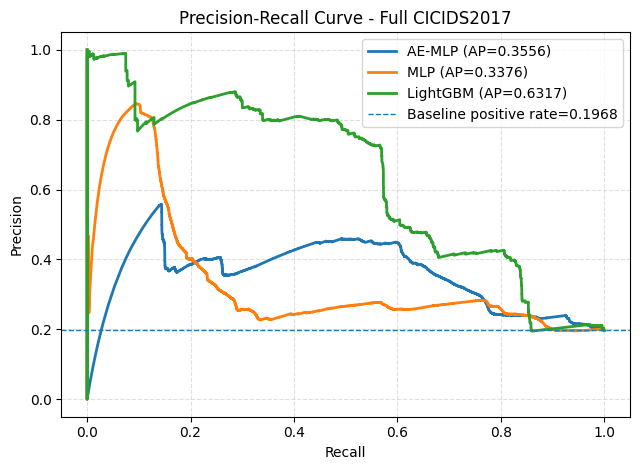

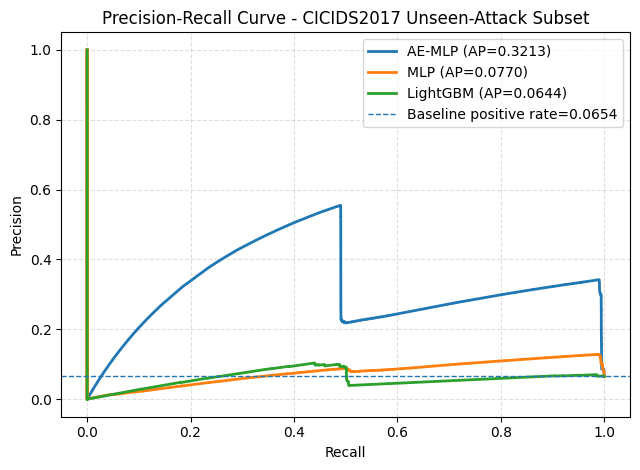

=== PR-AUC SUMMARY ===
                         Subset    Model  Average Precision / PR-AUC
                Full CICIDS2017   AE-MLP                    0.355589
                Full CICIDS2017      MLP                    0.337591
                Full CICIDS2017 LightGBM                    0.631654
CICIDS2017 Unseen-Attack Subset   AE-MLP                    0.321275
CICIDS2017 Unseen-Attack Subset      MLP                    0.076984
CICIDS2017 Unseen-Attack Subset LightGBM                    0.064400

Saved figures:
/content/drive/MyDrive/CICIDS2018/crossdataset_cicids2017_fair_results/fig_pr_curve_full_cicids2017.png
/content/drive/MyDrive/CICIDS2018/crossdataset_cicids2017_fair_results/fig_pr_curve_unseen_attack_cicids2017.png

Saved AP summary:
/content/drive/MyDrive/CICIDS2018/crossdataset_cicids2017_fair_results/paper_table_pr_auc_full_and_unseen_cicids2017.csv


In [ ]:
# ============================================================
# CELL 10 — PRECISION-RECALL CURVES FOR FULL AND UNSEEN CICIDS2017
# ============================================================

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd

def plot_pr_curves(y_true_input, probs_dict, subset_name, out_path):
    plt.figure(figsize=(6.5, 4.8))

    ap_rows = []

    for model_name, p in probs_dict.items():
        precision, recall, _ = precision_recall_curve(y_true_input, p)
        ap = average_precision_score(y_true_input, p)

        plt.plot(recall, precision, linewidth=2, label=f"{model_name} (AP={ap:.4f})")

        ap_rows.append({
            "Subset": subset_name,
            "Model": model_name,
            "Average Precision / PR-AUC": ap
        })

    positive_rate = np.mean(y_true_input)
    plt.axhline(
        positive_rate,
        linestyle="--",
        linewidth=1,
        label=f"Baseline positive rate={positive_rate:.4f}"
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {subset_name}")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()

    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame(ap_rows)

# Full CICIDS2017 PR curve
pr_full_path = os.path.join(
    OUT_DIR,
    "fig_pr_curve_full_cicids2017.png"
)

df_ap_full = plot_pr_curves(
    y_true_input=y_true,
    probs_dict=probs,
    subset_name="Full CICIDS2017",
    out_path=pr_full_path
)

# Unseen-attack subset PR curve
probs_unseen = {
    model_name: p_full[mask_unseen]
    for model_name, p_full in probs.items()
}

pr_unseen_path = os.path.join(
    OUT_DIR,
    "fig_pr_curve_unseen_attack_cicids2017.png"
)

df_ap_unseen = plot_pr_curves(
    y_true_input=y_true_unseen,
    probs_dict=probs_unseen,
    subset_name="CICIDS2017 Unseen-Attack Subset",
    out_path=pr_unseen_path
)

df_ap_all = pd.concat([df_ap_full, df_ap_unseen], ignore_index=True)
df_ap_all["Average Precision / PR-AUC"] = df_ap_all["Average Precision / PR-AUC"].round(6)

ap_path = os.path.join(
    OUT_DIR,
    "paper_table_pr_auc_full_and_unseen_cicids2017.csv"
)

df_ap_all.to_csv(ap_path, index=False)

print("=== PR-AUC SUMMARY ===")
print(df_ap_all.to_string(index=False))

print("\nSaved figures:")
print(pr_full_path)
print(pr_unseen_path)

print("\nSaved AP summary:")
print(ap_path)

Loading CICIDS2018 test split...
X18 shape: (1759848, 38)
Labels shape: (1759848,)

CICIDS2018 category support:
BENIGN       : 1347726
Known Attack : 387943
Infiltration : 24179

Computing CICIDS2018 BENIGN reconstruction error...
Computing CICIDS2018 Known Attack reconstruction error...
Computing CICIDS2018 Infiltration reconstruction error...

Computing CICIDS2017 selected-label reconstruction errors...

Processing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

Processing: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv

Processing: Friday-WorkingHours-Morning.pcap_ISCX.csv

Processing: Monday-WorkingHours.pcap_ISCX.csv

Processing: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv

Processing: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv

Processing: Tuesday-WorkingHours.pcap_ISCX.csv

Processing: Wednesday-workingHours.pcap_ISCX.csv

CICIDS2017 selected-label support:
PortScan       : 158804
Heartbleed     : 11
Infiltration   : 36

=== RECONSTRUCTION E

/tmp/ipykernel_3287/1494007793.py:252: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


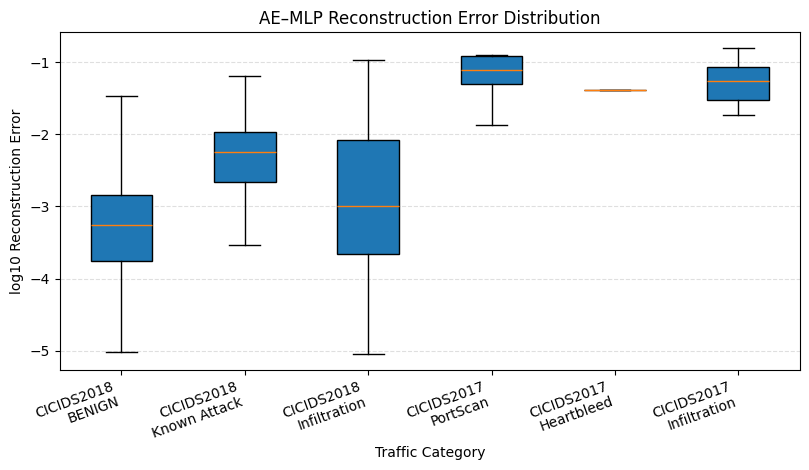


Saved figure:
/content/drive/MyDrive/CICIDS2018/crossdataset_cicids2017_fair_results/reconstruction_error/fig_reconstruction_error_distribution.png
/content/drive/MyDrive/CICIDS2018/crossdataset_cicids2017_fair_results/reconstruction_error/fig_reconstruction_error_distribution.pdf

Saved sampled plot data:
/content/drive/MyDrive/CICIDS2018/crossdataset_cicids2017_fair_results/reconstruction_error/reconstruction_error_plot_sample.csv

Cell 11 selesai. Reconstruction error evidence sudah siap.


In [ ]:
# ============================================================
# CELL 11 — RECONSTRUCTION ERROR DISTRIBUTION FOR AE-MLP
# Dataset:
# - CICIDS2018 BENIGN
# - CICIDS2018 Known Attack
# - CICIDS2018 Infiltration held-out
# - CICIDS2017 PortScan
# - CICIDS2017 Heartbleed
# - CICIDS2017 Infiltration
# ============================================================

import os, gc, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pastikan path tersedia
BASE_DIR = "/content/drive/MyDrive/CICIDS2018"
DATASET_SPLIT = os.path.join(BASE_DIR, "dataset_split.joblib")

OUT_DIR = os.path.join(BASE_DIR, "crossdataset_cicids2017_fair_results")
os.makedirs(OUT_DIR, exist_ok=True)

RECON_OUT_DIR = os.path.join(OUT_DIR, "reconstruction_error")
os.makedirs(RECON_OUT_DIR, exist_ok=True)

BATCH_SIZE = 4096
RECON_CHUNK_SIZE = 100000
PLOT_SAMPLE_PER_CLASS = 5000
EPS = 1e-12

def compute_reconstruction_error_scaled(X_scaled, chunk_size=RECON_CHUNK_SIZE):
    """
    Input harus sudah dalam feature space dan scaling yang sama dengan AE model.
    Output: reconstruction error per flow.
    """
    errors = []

    for start in range(0, len(X_scaled), chunk_size):
        end = min(start + chunk_size, len(X_scaled))
        X_chunk = X_scaled[start:end].astype("float32", copy=False)

        X_pred = ae_model.predict(
            X_chunk,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        err = np.mean((X_chunk - X_pred) ** 2, axis=1).astype("float32")
        errors.append(err)

        del X_chunk, X_pred, err
        gc.collect()

    return np.concatenate(errors)

def sample_for_plot(arr, n=PLOT_SAMPLE_PER_CLASS, seed=42):
    arr = np.asarray(arr)
    if len(arr) <= n:
        return arr

    rng = np.random.default_rng(seed)
    idx = rng.choice(len(arr), size=n, replace=False)
    return arr[idx]

def summarize_error(category, dataset, errors, benign_mean):
    errors = np.asarray(errors)

    return {
        "Category": category,
        "Dataset": dataset,
        "Support": int(len(errors)),
        "Mean": float(np.mean(errors)),
        "Median": float(np.median(errors)),
        "Std": float(np.std(errors)),
        "P75": float(np.percentile(errors, 75)),
        "P90": float(np.percentile(errors, 90)),
        "P95": float(np.percentile(errors, 95)),
        "Min": float(np.min(errors)),
        "Max": float(np.max(errors)),
        "Mean Ratio to CICIDS2018 Benign": float(np.mean(errors) / benign_mean) if benign_mean > 0 else np.nan,
    }

# ============================================================
# Part A — CICIDS2018 reconstruction errors
# ============================================================

print("=" * 80)
print("Loading CICIDS2018 test split...")
print("=" * 80)

data18 = joblib.load(DATASET_SPLIT)

X18 = data18["X_test"].astype("float32")
labels18 = np.array([str(x).strip() for x in data18["label_test"]])

print("X18 shape:", X18.shape)
print("Labels shape:", labels18.shape)

labels18_lower = np.array([x.lower() for x in labels18])

mask_18_benign = labels18_lower == "benign"
mask_18_infiltration = np.array(["infiltration" in x for x in labels18_lower])
mask_18_known_attack = (~mask_18_benign) & (~mask_18_infiltration)

print("\nCICIDS2018 category support:")
print("BENIGN       :", int(mask_18_benign.sum()))
print("Known Attack :", int(mask_18_known_attack.sum()))
print("Infiltration :", int(mask_18_infiltration.sum()))

print("\nComputing CICIDS2018 BENIGN reconstruction error...")
err_18_benign = compute_reconstruction_error_scaled(X18[mask_18_benign])

print("Computing CICIDS2018 Known Attack reconstruction error...")
err_18_known = compute_reconstruction_error_scaled(X18[mask_18_known_attack])

print("Computing CICIDS2018 Infiltration reconstruction error...")
err_18_infiltration = compute_reconstruction_error_scaled(X18[mask_18_infiltration])

# Bersihkan X18 dari memory
del data18, X18
gc.collect()

# ============================================================
# Part B — CICIDS2017 selected unseen/cross-dataset labels
# ============================================================

print("\n" + "=" * 80)
print("Computing CICIDS2017 selected-label reconstruction errors...")
print("=" * 80)

selected_17_labels = ["PortScan", "Heartbleed", "Infiltration"]
err17_dict = {lbl: [] for lbl in selected_17_labels}

for csv_path in csv_files:
    fname = os.path.basename(csv_path)
    print("\nProcessing:", fname)

    for chunk in pd.read_csv(
        csv_path,
        chunksize=100000,
        encoding="latin1",
        low_memory=False
    ):
        # prepare_chunk_raw sudah dibuat di cell sebelumnya
        X_raw, y_valid, labels_valid, labels_invalid = prepare_chunk_raw(chunk, fname)

        labels_valid = np.asarray(labels_valid).astype(str)
        mask_selected = np.isin(labels_valid, selected_17_labels)

        if mask_selected.sum() == 0:
            del chunk, X_raw, y_valid, labels_valid, labels_invalid
            gc.collect()
            continue

        X_selected_raw = X_raw[mask_selected]
        labels_selected = labels_valid[mask_selected]

        # Pakai scaler AE-MLP karena reconstruction error berasal dari AE-MLP
        X_selected_scaled = scalers["AE-MLP"].transform(X_selected_raw).astype("float32")

        err_selected = compute_reconstruction_error_scaled(
            X_selected_scaled,
            chunk_size=RECON_CHUNK_SIZE
        )

        for lbl in selected_17_labels:
            lbl_mask = labels_selected == lbl
            if lbl_mask.sum() > 0:
                err17_dict[lbl].append(err_selected[lbl_mask])

        del chunk, X_raw, y_valid, labels_valid, labels_invalid
        del X_selected_raw, labels_selected, X_selected_scaled, err_selected
        gc.collect()

# Concatenate CICIDS2017 errors
for lbl in selected_17_labels:
    if len(err17_dict[lbl]) > 0:
        err17_dict[lbl] = np.concatenate(err17_dict[lbl])
    else:
        err17_dict[lbl] = np.array([], dtype="float32")

print("\nCICIDS2017 selected-label support:")
for lbl in selected_17_labels:
    print(f"{lbl:<15}: {len(err17_dict[lbl])}")

# ============================================================
# Part C — Summary table
# ============================================================

benign_mean = float(np.mean(err_18_benign))

summary_rows = [
    summarize_error("BENIGN", "CICIDS2018", err_18_benign, benign_mean),
    summarize_error("Known Attack", "CICIDS2018", err_18_known, benign_mean),
    summarize_error("Infiltration", "CICIDS2018 Held-out", err_18_infiltration, benign_mean),
]

for lbl in selected_17_labels:
    if len(err17_dict[lbl]) > 0:
        summary_rows.append(
            summarize_error(lbl, "CICIDS2017", err17_dict[lbl], benign_mean)
        )

df_recon_summary = pd.DataFrame(summary_rows)

round_cols = [
    "Mean", "Median", "Std", "P75", "P90", "P95", "Min", "Max",
    "Mean Ratio to CICIDS2018 Benign"
]

for c in round_cols:
    df_recon_summary[c] = df_recon_summary[c].round(8)

recon_summary_path = os.path.join(
    RECON_OUT_DIR,
    "reconstruction_error_summary.csv"
)

df_recon_summary.to_csv(recon_summary_path, index=False)

print("\n=== RECONSTRUCTION ERROR SUMMARY ===")
print(df_recon_summary.to_string(index=False))

print("\nSaved summary:")
print(recon_summary_path)

# ============================================================
# Part D — Paper-ready figure
# ============================================================

plot_items = [
    ("CICIDS2018\nBENIGN", err_18_benign),
    ("CICIDS2018\nKnown Attack", err_18_known),
    ("CICIDS2018\nInfiltration", err_18_infiltration),
    ("CICIDS2017\nPortScan", err17_dict["PortScan"]),
    ("CICIDS2017\nHeartbleed", err17_dict["Heartbleed"]),
    ("CICIDS2017\nInfiltration", err17_dict["Infiltration"]),
]

plot_labels = []
plot_data = []

for label, arr in plot_items:
    if len(arr) > 0:
        plot_labels.append(label)
        sampled = sample_for_plot(arr, n=PLOT_SAMPLE_PER_CLASS)
        plot_data.append(np.log10(sampled + EPS))

plt.figure(figsize=(8.2, 4.8))

box = plt.boxplot(
    plot_data,
    labels=plot_labels,
    showfliers=False,
    patch_artist=True
)

plt.ylabel("log10 Reconstruction Error")
plt.xlabel("Traffic Category")
plt.title("AE–MLP Reconstruction Error Distribution")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

fig_path_png = os.path.join(
    RECON_OUT_DIR,
    "fig_reconstruction_error_distribution.png"
)

fig_path_pdf = os.path.join(
    RECON_OUT_DIR,
    "fig_reconstruction_error_distribution.pdf"
)

plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.show()

print("\nSaved figure:")
print(fig_path_png)
print(fig_path_pdf)

# ============================================================
# Part E — Save sampled plot data for reproducibility
# ============================================================

sampled_rows = []

for label, arr in plot_items:
    if len(arr) > 0:
        sampled = sample_for_plot(arr, n=PLOT_SAMPLE_PER_CLASS)
        for v in sampled:
            sampled_rows.append({
                "Category": label.replace("\n", " "),
                "Reconstruction_Error": float(v),
                "Log10_Reconstruction_Error": float(np.log10(v + EPS))
            })

df_recon_plot_sample = pd.DataFrame(sampled_rows)

plot_data_path = os.path.join(
    RECON_OUT_DIR,
    "reconstruction_error_plot_sample.csv"
)

df_recon_plot_sample.to_csv(plot_data_path, index=False)

print("\nSaved sampled plot data:")
print(plot_data_path)

print("\nCell 11 selesai. Reconstruction error evidence sudah siap.")

=== HARDCODED RECONSTRUCTION ERROR EVIDENCE ===
          Category    Dataset  Mean Reconstruction Error / MSE  Ratio to Benign Train                   Source
     AE train loss CICIDS2018                         0.001775                    NaN Original AE–MLP notebook
AE validation loss CICIDS2018                         0.001690                    NaN Original AE–MLP notebook
      Benign train CICIDS2018                         0.001691                 1.0000 Original AE–MLP notebook
      Attack train CICIDS2018                         0.007522                 4.4483 Original AE–MLP notebook


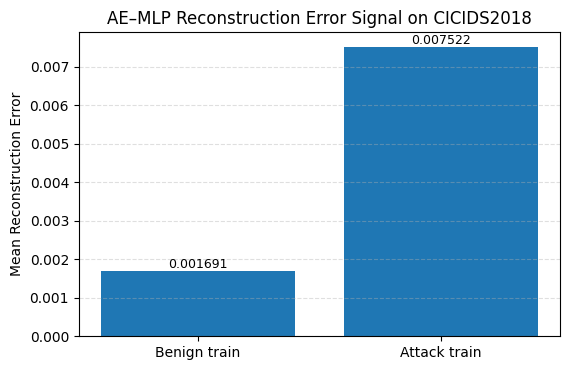


=== HARDCODED CICIDS2018 AE–MLP MAIN METRICS ===
 Model                  Dataset  Threshold  Accuracy (%)  F1-score (%)  FPR (%)  Recall / Detection Rate (%)  PR-AUC  ROC-AUC     TP    FN   FP      TN  Normal support  Attack support  Total support
AE–MLP CSE-CIC-IDS2018 Test Set       0.72       98.5111       96.7407   0.2192                      94.3588  0.9744   0.9788 388877 23249 2954 1344768         1347722          412126        1759848

=== HARDCODED CICIDS2018 AE–MLP ZERO-DAY INFILTRATION ===
 Model                  Dataset Held-out Label  Threshold  Total Infiltration Samples  Detected as Attack  Missed / Not Detected  Detection Rate (%)  Miss Rate (%)  Mean P(Attack) - Infiltration  Mean P(Attack) - Normal Test  Mean P(Attack) - Known Attack
AE–MLP CSE-CIC-IDS2018 Test Set   Infiltration       0.72                       24180                1969                  22211                8.14          91.86                         0.1073                        0.0041             

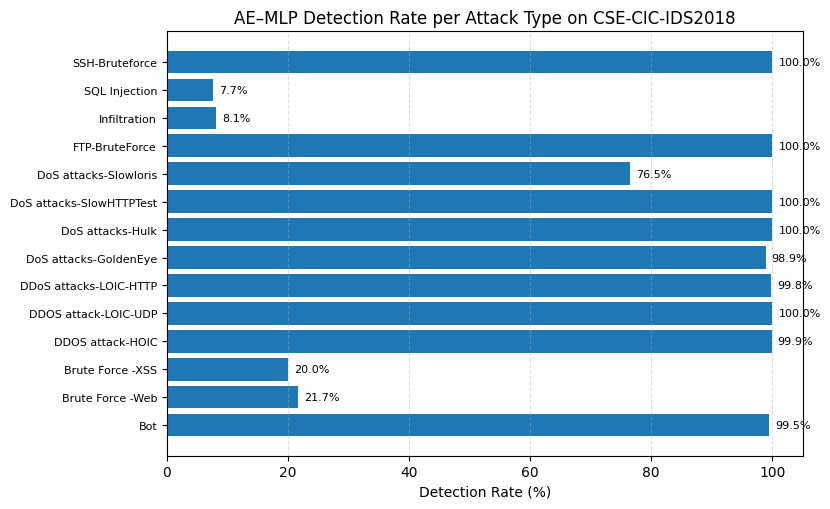


Saved files:
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/cicids2018_ae_mlp_hardcoded_setup.csv
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/cicids2018_ae_mlp_hardcoded_reconstruction_error.csv
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/cicids2018_ae_mlp_hardcoded_main_metrics.csv
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/cicids2018_ae_mlp_hardcoded_zero_day_infiltration.csv
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/cicids2018_ae_mlp_hardcoded_per_class_detection.csv
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/fig_cicids2018_hardcoded_mean_reconstruction_error.png
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/fig_cicids2018_hardcoded_mean_reconstruction_error.pdf
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/fig_cicids2018_ae_mlp_hardcoded_per_class_detection.png
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/fig_cicids2018_ae_ml

In [ ]:
# ============================================================
# HARD-CODED EVIDENCE CELL — CICIDS2018 AE–MLP
# Source: original AE–MLP notebook output
# Purpose:
# 1. Mengunci angka lama CICIDS2018
# 2. Membuat CSV evidence
# 3. Membuat figure mean reconstruction error yang hemat halaman
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = "/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence"
os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# A. CICIDS2018 dataset and training setup
# ============================================================

setup_rows = [
    {
        "Item": "Input features",
        "Value": "38 features"
    },
    {
        "Item": "Train samples",
        "Value": "8,212,670"
    },
    {
        "Item": "Validation samples",
        "Value": "1,759,887"
    },
    {
        "Item": "Test samples",
        "Value": "1,759,848"
    },
    {
        "Item": "AE training data",
        "Value": "6,289,506 benign samples only"
    },
    {
        "Item": "AE validation data",
        "Value": "1,347,786 benign samples only"
    },
    {
        "Item": "MLP training data",
        "Value": "8,099,910 samples excluding Infiltration"
    },
    {
        "Item": "Held-out zero-day label",
        "Value": "Infiltration"
    },
    {
        "Item": "Infiltration samples hidden from train",
        "Value": "112,760"
    },
    {
        "Item": "Infiltration test samples",
        "Value": "24,180"
    },
    {
        "Item": "AE architecture",
        "Value": "38 -> 32 -> 16 -> 8 -> 16 -> 32 -> 38"
    },
    {
        "Item": "MLP on AE latent architecture",
        "Value": "9 -> 128 -> 64 -> 1"
    },
]

df_setup = pd.DataFrame(setup_rows)

setup_path = os.path.join(
    OUT_DIR,
    "cicids2018_ae_mlp_hardcoded_setup.csv"
)

df_setup.to_csv(setup_path, index=False)

# ============================================================
# B. AE convergence and reconstruction-error evidence
# ============================================================

df_recon_hardcoded = pd.DataFrame([
    {
        "Category": "AE train loss",
        "Dataset": "CICIDS2018",
        "Mean Reconstruction Error / MSE": 0.001775,
        "Ratio to Benign Train": np.nan,
        "Source": "Original AE–MLP notebook"
    },
    {
        "Category": "AE validation loss",
        "Dataset": "CICIDS2018",
        "Mean Reconstruction Error / MSE": 0.001690,
        "Ratio to Benign Train": np.nan,
        "Source": "Original AE–MLP notebook"
    },
    {
        "Category": "Benign train",
        "Dataset": "CICIDS2018",
        "Mean Reconstruction Error / MSE": 0.001691,
        "Ratio to Benign Train": 1.0,
        "Source": "Original AE–MLP notebook"
    },
    {
        "Category": "Attack train",
        "Dataset": "CICIDS2018",
        "Mean Reconstruction Error / MSE": 0.007522,
        "Ratio to Benign Train": 0.007522 / 0.001691,
        "Source": "Original AE–MLP notebook"
    },
])

df_recon_hardcoded["Ratio to Benign Train"] = df_recon_hardcoded[
    "Ratio to Benign Train"
].round(4)

recon_path = os.path.join(
    OUT_DIR,
    "cicids2018_ae_mlp_hardcoded_reconstruction_error.csv"
)

df_recon_hardcoded.to_csv(recon_path, index=False)

print("=== HARDCODED RECONSTRUCTION ERROR EVIDENCE ===")
print(df_recon_hardcoded.to_string(index=False))

# Figure: mean reconstruction error
plot_df = df_recon_hardcoded[
    df_recon_hardcoded["Category"].isin(["Benign train", "Attack train"])
].copy()

plt.figure(figsize=(5.8, 3.8))
bars = plt.bar(
    plot_df["Category"],
    plot_df["Mean Reconstruction Error / MSE"]
)

for bar, val in zip(bars, plot_df["Mean Reconstruction Error / MSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.6f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.ylabel("Mean Reconstruction Error")
plt.title("AE–MLP Reconstruction Error Signal on CICIDS2018")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

fig_recon_mean_png = os.path.join(
    OUT_DIR,
    "fig_cicids2018_hardcoded_mean_reconstruction_error.png"
)

fig_recon_mean_pdf = os.path.join(
    OUT_DIR,
    "fig_cicids2018_hardcoded_mean_reconstruction_error.pdf"
)

plt.savefig(fig_recon_mean_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_recon_mean_pdf, bbox_inches="tight")
plt.show()

# ============================================================
# C. CICIDS2018 AE–MLP main binary metrics
# ============================================================

df_main_metrics = pd.DataFrame([
    {
        "Model": "AE–MLP",
        "Dataset": "CSE-CIC-IDS2018 Test Set",
        "Threshold": 0.72,
        "Accuracy (%)": 98.5111,
        "F1-score (%)": 96.7407,
        "FPR (%)": 0.2192,
        "Recall / Detection Rate (%)": 94.3588,
        "PR-AUC": 0.9744,
        "ROC-AUC": 0.9788,
        "TP": 388877,
        "FN": 23249,
        "FP": 2954,
        "TN": 1344768,
        "Normal support": 1347722,
        "Attack support": 412126,
        "Total support": 1759848
    }
])

main_metrics_path = os.path.join(
    OUT_DIR,
    "cicids2018_ae_mlp_hardcoded_main_metrics.csv"
)

df_main_metrics.to_csv(main_metrics_path, index=False)

print("\n=== HARDCODED CICIDS2018 AE–MLP MAIN METRICS ===")
print(df_main_metrics.to_string(index=False))

# ============================================================
# D. CICIDS2018 zero-day / held-out Infiltration evidence
# ============================================================

df_zero_day = pd.DataFrame([
    {
        "Model": "AE–MLP",
        "Dataset": "CSE-CIC-IDS2018 Test Set",
        "Held-out Label": "Infiltration",
        "Threshold": 0.72,
        "Total Infiltration Samples": 24180,
        "Detected as Attack": 1969,
        "Missed / Not Detected": 22211,
        "Detection Rate (%)": 8.14,
        "Miss Rate (%)": 91.86,
        "Mean P(Attack) - Infiltration": 0.1073,
        "Mean P(Attack) - Normal Test": 0.0041,
        "Mean P(Attack) - Known Attack": 0.9939
    }
])

zero_day_path = os.path.join(
    OUT_DIR,
    "cicids2018_ae_mlp_hardcoded_zero_day_infiltration.csv"
)

df_zero_day.to_csv(zero_day_path, index=False)

print("\n=== HARDCODED CICIDS2018 AE–MLP ZERO-DAY INFILTRATION ===")
print(df_zero_day.to_string(index=False))

# ============================================================
# E. CICIDS2018 AE–MLP per-class detection rate
# ============================================================

per_class_rows = [
    ["Bot", 42928, 42695, 99.5, 0.9817, ""],
    ["Brute Force -Web", 92, 20, 21.7, 0.2945, "low-support"],
    ["Brute Force -XSS", 35, 7, 20.0, 0.3514, "low-support"],
    ["DDOS attack-HOIC", 102902, 102818, 99.9, 0.9922, ""],
    ["DDOS attack-LOIC-UDP", 260, 260, 100.0, 1.0000, "small class"],
    ["DDoS attacks-LOIC-HTTP", 86428, 86286, 99.8, 0.9973, ""],
    ["DoS attacks-GoldenEye", 6227, 6159, 98.9, 0.9795, ""],
    ["DoS attacks-Hulk", 69287, 69276, 100.0, 0.9980, ""],
    ["DoS attacks-SlowHTTPTest", 20983, 20983, 100.0, 0.9997, ""],
    ["DoS attacks-Slowloris", 1648, 1261, 76.5, 0.9066, "stealth/low-volume"],
    ["FTP-BruteForce", 29004, 29004, 100.0, 0.9998, ""],
    ["Infiltration", 24180, 1969, 8.1, 0.1073, "held-out zero-day"],
    ["SQL Injection", 13, 1, 7.7, 0.1677, "very low-support"],
    ["SSH-Bruteforce", 28139, 28138, 100.0, 0.9992, ""],
]

df_per_class = pd.DataFrame(
    per_class_rows,
    columns=[
        "Attack Type",
        "Support",
        "Detected as Attack",
        "Detection Rate (%)",
        "Mean P(Attack)",
        "Note"
    ]
)

per_class_path = os.path.join(
    OUT_DIR,
    "cicids2018_ae_mlp_hardcoded_per_class_detection.csv"
)

df_per_class.to_csv(per_class_path, index=False)

print("\n=== HARDCODED CICIDS2018 AE–MLP PER-CLASS DETECTION ===")
print(df_per_class.to_string(index=False))

# Figure: per-class detection rate
plt.figure(figsize=(8.4, 5.2))
y_pos = np.arange(len(df_per_class))

plt.barh(
    y_pos,
    df_per_class["Detection Rate (%)"]
)

plt.yticks(y_pos, df_per_class["Attack Type"], fontsize=8)
plt.xlabel("Detection Rate (%)")
plt.title("AE–MLP Detection Rate per Attack Type on CSE-CIC-IDS2018")
plt.xlim(0, 105)
plt.grid(axis="x", linestyle="--", alpha=0.4)

for i, val in enumerate(df_per_class["Detection Rate (%)"]):
    plt.text(
        val + 1,
        i,
        f"{val:.1f}%",
        va="center",
        fontsize=8
    )

plt.tight_layout()

fig_per_class_png = os.path.join(
    OUT_DIR,
    "fig_cicids2018_ae_mlp_hardcoded_per_class_detection.png"
)

fig_per_class_pdf = os.path.join(
    OUT_DIR,
    "fig_cicids2018_ae_mlp_hardcoded_per_class_detection.pdf"
)

plt.savefig(fig_per_class_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_per_class_pdf, bbox_inches="tight")
plt.show()

# ============================================================
# F. Save a small README / manifest
# ============================================================

manifest_text = f"""
Hardcoded CICIDS2018 AE–MLP evidence generated from original notebook output.

Files:
1. {os.path.basename(setup_path)}
2. {os.path.basename(recon_path)}
3. {os.path.basename(main_metrics_path)}
4. {os.path.basename(zero_day_path)}
5. {os.path.basename(per_class_path)}
6. {os.path.basename(fig_recon_mean_png)}
7. {os.path.basename(fig_per_class_png)}

Important notes:
- These values are hardcoded from the original AE–MLP CICIDS2018 notebook output.
- Main CICIDS2018 classification metrics can be used as the original paper result.
- For reconstruction-error distribution boxplot, use the non-hardcoded Cell 11 output because it uses per-sample reconstruction errors.
- The hardcoded reconstruction figure only shows mean reconstruction-error evidence, not the full distribution.
"""

manifest_path = os.path.join(
    OUT_DIR,
    "README_hardcoded_cicids2018_ae_mlp_evidence.txt"
)

with open(manifest_path, "w") as f:
    f.write(manifest_text)

print("\nSaved files:")
for p in [
    setup_path,
    recon_path,
    main_metrics_path,
    zero_day_path,
    per_class_path,
    fig_recon_mean_png,
    fig_recon_mean_pdf,
    fig_per_class_png,
    fig_per_class_pdf,
    manifest_path
]:
    print(p)

print("\nHardcoded CICIDS2018 AE–MLP evidence selesai.")

Reconstruction error P99 benign reference threshold:
0.02029970

=== HISTOGRAM THRESHOLD SUMMARY ===
                                 Group  Support     Mean   Median      P95      P99  Above P99 Benign Threshold (%)
                     CICIDS2018 Benign  1347726 0.001693 0.000540 0.007009 0.020300                        1.000055
               CICIDS2018 Known Attack   387943 0.007656 0.005668 0.018519 0.018844                        0.639527
Held-out / Cross-dataset Unseen Attack   183030 0.074981 0.049959 0.125974 0.126238                       86.859531

Saved summary:
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/reconstruction_error/reconstruction_error_histogram_threshold_summary.csv


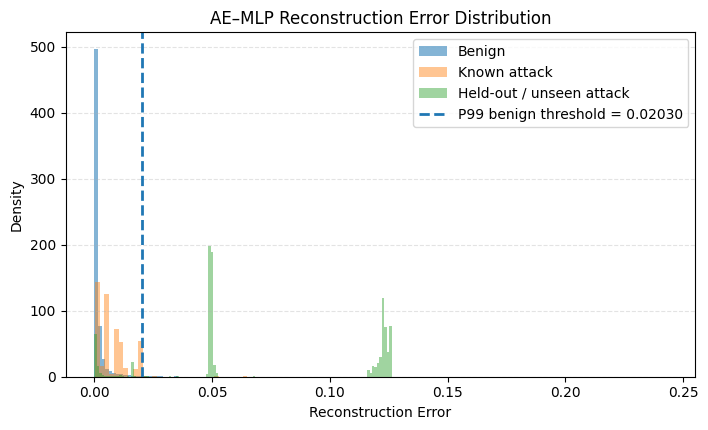

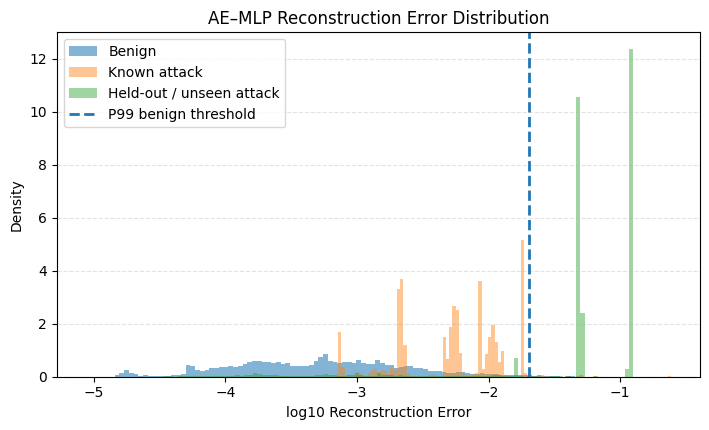


Saved figures:
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/reconstruction_error/fig_reconstruction_error_histogram_threshold_raw.png
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/reconstruction_error/fig_reconstruction_error_histogram_threshold_raw.pdf
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/reconstruction_error/fig_reconstruction_error_histogram_threshold_log10.png
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/reconstruction_error/fig_reconstruction_error_histogram_threshold_log10.pdf

Cell 12 selesai.


In [ ]:
# ============================================================
# CELL 12 — HISTOGRAM RECONSTRUCTION ERROR WITH THRESHOLD
# IEEE-style figure
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

HIST_OUT_DIR = os.path.join(
    OUT_DIR,
    "reconstruction_error"
)

os.makedirs(HIST_OUT_DIR, exist_ok=True)

EPS = 1e-12
PLOT_SAMPLE = 50000

def sample_array(arr, n=PLOT_SAMPLE, seed=42):
    arr = np.asarray(arr)
    if len(arr) <= n:
        return arr
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(arr), size=n, replace=False)
    return arr[idx]

# ============================================================
# A. Build anomaly groups
# ============================================================

benign_err = err_18_benign
known_attack_err = err_18_known

unseen_err_list = [
    err_18_infiltration,
    err17_dict["PortScan"],
    err17_dict["Heartbleed"],
    err17_dict["Infiltration"]
]

unseen_err = np.concatenate([
    x for x in unseen_err_list if len(x) > 0
])

# ============================================================
# B. Reconstruction-error reference threshold
# ============================================================
# Untuk visualisasi paper:
# Pakai P99 dari benign reconstruction error sebagai reference threshold.
# Ini bukan threshold classifier AE–MLP 0.72.

recon_threshold_p99 = np.percentile(benign_err, 99)

print("Reconstruction error P99 benign reference threshold:")
print(f"{recon_threshold_p99:.8f}")

# ============================================================
# C. Summary table
# ============================================================

summary_hist = pd.DataFrame([
    {
        "Group": "CICIDS2018 Benign",
        "Support": len(benign_err),
        "Mean": np.mean(benign_err),
        "Median": np.median(benign_err),
        "P95": np.percentile(benign_err, 95),
        "P99": np.percentile(benign_err, 99),
        "Above P99 Benign Threshold (%)": np.mean(benign_err > recon_threshold_p99) * 100
    },
    {
        "Group": "CICIDS2018 Known Attack",
        "Support": len(known_attack_err),
        "Mean": np.mean(known_attack_err),
        "Median": np.median(known_attack_err),
        "P95": np.percentile(known_attack_err, 95),
        "P99": np.percentile(known_attack_err, 99),
        "Above P99 Benign Threshold (%)": np.mean(known_attack_err > recon_threshold_p99) * 100
    },
    {
        "Group": "Held-out / Cross-dataset Unseen Attack",
        "Support": len(unseen_err),
        "Mean": np.mean(unseen_err),
        "Median": np.median(unseen_err),
        "P95": np.percentile(unseen_err, 95),
        "P99": np.percentile(unseen_err, 99),
        "Above P99 Benign Threshold (%)": np.mean(unseen_err > recon_threshold_p99) * 100
    }
])

for c in ["Mean", "Median", "P95", "P99", "Above P99 Benign Threshold (%)"]:
    summary_hist[c] = summary_hist[c].round(6)

summary_hist_path = os.path.join(
    HIST_OUT_DIR,
    "reconstruction_error_histogram_threshold_summary.csv"
)

summary_hist.to_csv(summary_hist_path, index=False)

print("\n=== HISTOGRAM THRESHOLD SUMMARY ===")
print(summary_hist.to_string(index=False))

print("\nSaved summary:")
print(summary_hist_path)

# ============================================================
# D. Plot in raw reconstruction error scale
# ============================================================

benign_plot = sample_array(benign_err)
known_plot = sample_array(known_attack_err)
unseen_plot = sample_array(unseen_err)

plt.figure(figsize=(7.2, 4.4))

plt.hist(
    benign_plot,
    bins=120,
    alpha=0.55,
    density=True,
    label="Benign"
)

plt.hist(
    known_plot,
    bins=120,
    alpha=0.45,
    density=True,
    label="Known attack"
)

plt.hist(
    unseen_plot,
    bins=120,
    alpha=0.45,
    density=True,
    label="Held-out / unseen attack"
)

plt.axvline(
    recon_threshold_p99,
    linestyle="--",
    linewidth=2,
    label=f"P99 benign threshold = {recon_threshold_p99:.5f}"
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("AE–MLP Reconstruction Error Distribution")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()

hist_raw_png = os.path.join(
    HIST_OUT_DIR,
    "fig_reconstruction_error_histogram_threshold_raw.png"
)

hist_raw_pdf = os.path.join(
    HIST_OUT_DIR,
    "fig_reconstruction_error_histogram_threshold_raw.pdf"
)

plt.savefig(hist_raw_png, dpi=300, bbox_inches="tight")
plt.savefig(hist_raw_pdf, bbox_inches="tight")
plt.show()

# ============================================================
# E. Plot in log10 reconstruction error scale
# ============================================================
# Ini biasanya lebih rapi untuk paper karena reconstruction error sangat skewed.

plt.figure(figsize=(7.2, 4.4))

plt.hist(
    np.log10(benign_plot + EPS),
    bins=120,
    alpha=0.55,
    density=True,
    label="Benign"
)

plt.hist(
    np.log10(known_plot + EPS),
    bins=120,
    alpha=0.45,
    density=True,
    label="Known attack"
)

plt.hist(
    np.log10(unseen_plot + EPS),
    bins=120,
    alpha=0.45,
    density=True,
    label="Held-out / unseen attack"
)

plt.axvline(
    np.log10(recon_threshold_p99 + EPS),
    linestyle="--",
    linewidth=2,
    label="P99 benign threshold"
)

plt.xlabel("log10 Reconstruction Error")
plt.ylabel("Density")
plt.title("AE–MLP Reconstruction Error Distribution")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()

hist_log_png = os.path.join(
    HIST_OUT_DIR,
    "fig_reconstruction_error_histogram_threshold_log10.png"
)

hist_log_pdf = os.path.join(
    HIST_OUT_DIR,
    "fig_reconstruction_error_histogram_threshold_log10.pdf"
)

plt.savefig(hist_log_png, dpi=300, bbox_inches="tight")
plt.savefig(hist_log_pdf, bbox_inches="tight")
plt.show()

print("\nSaved figures:")
print(hist_raw_png)
print(hist_raw_pdf)
print(hist_log_png)
print(hist_log_pdf)

print("\nCell 12 selesai.")

=== PAPER-READY RECONSTRUCTION ERROR SUMMARY ===
               Category  Support     Mean   Median      P75      P90      P95      P99  Mean ratio to benign  Above P99 benign threshold (%)
      Benign CICIDS2018  1347726 0.001693 0.000540 0.001477 0.003610 0.007009 0.020300              1.000000                        1.000055
Known attack CICIDS2018   387943 0.007656 0.005668 0.010649 0.018469 0.018519 0.018844              4.521765                        0.639527
Infiltration CICIDS2018    24179 0.005468 0.001013 0.006969 0.016181 0.016276 0.041320              3.229504                        3.201125
    PortScan CICIDS2017   158804 0.085571 0.051656 0.122829 0.125031 0.125988 0.126238             50.539299                       99.595728
  Heartbleed CICIDS2017       11 0.039888 0.041271 0.041579 0.041701 0.042261 0.042709             23.558331                      100.000000
Infiltration CICIDS2017       36 0.056663 0.054834 0.084530 0.092790 0.097304 0.139410             33.465

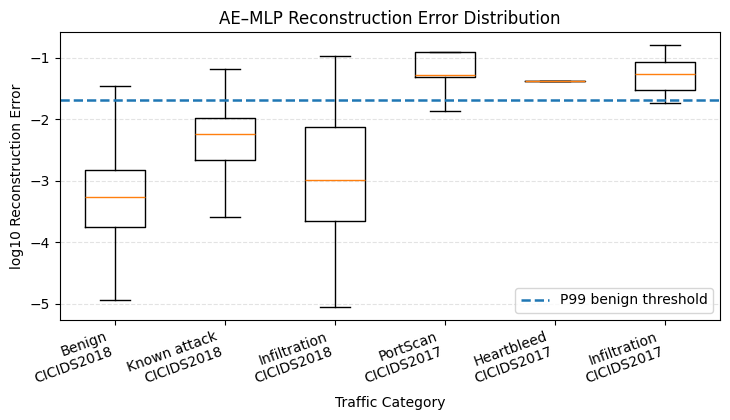


Saved figure:
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/reconstruction_error/paper_ready/fig_paper_ready_reconstruction_error_boxplot.png
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/reconstruction_error/paper_ready/fig_paper_ready_reconstruction_error_boxplot.pdf


In [ ]:
# ============================================================
# CELL 13 — PAPER-READY BOXPLOT RECONSTRUCTION ERROR
# Recommended for IEEE paper
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PAPER_FIG_DIR = os.path.join(
    OUT_DIR,
    "reconstruction_error",
    "paper_ready"
)

os.makedirs(PAPER_FIG_DIR, exist_ok=True)

EPS = 1e-12
SAMPLE_PER_GROUP = 10000

def sample_for_plot(arr, n=SAMPLE_PER_GROUP, seed=42):
    arr = np.asarray(arr)
    if len(arr) <= n:
        return arr

    rng = np.random.default_rng(seed)
    idx = rng.choice(len(arr), size=n, replace=False)
    return arr[idx]

# P99 benign reference threshold
recon_threshold_p99 = np.percentile(err_18_benign, 99)
log_threshold = np.log10(recon_threshold_p99 + EPS)

plot_groups = [
    {
        "Label": "Benign\nCICIDS2018",
        "Array": err_18_benign
    },
    {
        "Label": "Known attack\nCICIDS2018",
        "Array": err_18_known
    },
    {
        "Label": "Infiltration\nCICIDS2018",
        "Array": err_18_infiltration
    },
    {
        "Label": "PortScan\nCICIDS2017",
        "Array": err17_dict["PortScan"]
    },
    {
        "Label": "Heartbleed\nCICIDS2017",
        "Array": err17_dict["Heartbleed"]
    },
    {
        "Label": "Infiltration\nCICIDS2017",
        "Array": err17_dict["Infiltration"]
    },
]

labels = []
data_log = []
summary_rows = []

benign_mean = np.mean(err_18_benign)

for group in plot_groups:
    label = group["Label"]
    arr = np.asarray(group["Array"])

    if len(arr) == 0:
        continue

    sampled = sample_for_plot(arr)
    sampled_log = np.log10(sampled + EPS)

    labels.append(label)
    data_log.append(sampled_log)

    summary_rows.append({
        "Category": label.replace("\n", " "),
        "Support": len(arr),
        "Mean": np.mean(arr),
        "Median": np.median(arr),
        "P75": np.percentile(arr, 75),
        "P90": np.percentile(arr, 90),
        "P95": np.percentile(arr, 95),
        "P99": np.percentile(arr, 99),
        "Mean ratio to benign": np.mean(arr) / benign_mean,
        "Above P99 benign threshold (%)": np.mean(arr > recon_threshold_p99) * 100
    })

df_box_summary = pd.DataFrame(summary_rows)

for col in [
    "Mean", "Median", "P75", "P90", "P95", "P99",
    "Mean ratio to benign", "Above P99 benign threshold (%)"
]:
    df_box_summary[col] = df_box_summary[col].round(6)

summary_path = os.path.join(
    PAPER_FIG_DIR,
    "paper_ready_reconstruction_error_boxplot_summary.csv"
)

df_box_summary.to_csv(summary_path, index=False)

print("=== PAPER-READY RECONSTRUCTION ERROR SUMMARY ===")
print(df_box_summary.to_string(index=False))
print("\nP99 benign threshold:", round(recon_threshold_p99, 8))
print("Saved summary:", summary_path)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(7.4, 4.3))

plt.boxplot(
    data_log,
    tick_labels=labels,
    showfliers=False,
    widths=0.55
)

plt.axhline(
    log_threshold,
    linestyle="--",
    linewidth=1.8,
    label="P99 benign threshold"
)

plt.ylabel("log10 Reconstruction Error")
plt.xlabel("Traffic Category")
plt.title("AE–MLP Reconstruction Error Distribution")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend(loc="lower right")
plt.tight_layout()

fig_png = os.path.join(
    PAPER_FIG_DIR,
    "fig_paper_ready_reconstruction_error_boxplot.png"
)

fig_pdf = os.path.join(
    PAPER_FIG_DIR,
    "fig_paper_ready_reconstruction_error_boxplot.pdf"
)

plt.savefig(fig_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_pdf, bbox_inches="tight")
plt.show()

print("\nSaved figure:")
print(fig_png)
print(fig_pdf)

=== PAPER RECONSTRUCTION ERROR SUMMARY ===
             Category  Support     Mean   Median      P75      P90      P95  Mean ratio to benign
               Benign  1347726 0.001693 0.000540 0.001477 0.003610 0.007009              1.000000
         Known Attack   387943 0.007656 0.005668 0.010649 0.018469 0.018519              4.521765
Held-out Infiltration    24179 0.005468 0.001013 0.006969 0.016181 0.016276              3.229504

Saved summary: /content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/reconstruction_error/paper_ready/paper_reconstruction_error_cicids2018_summary.csv


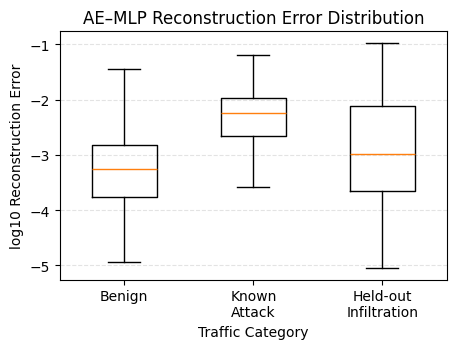


Saved figure:
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/reconstruction_error/paper_ready/fig_reconstruction_error_cicids2018_boxplot.png
/content/drive/MyDrive/CICIDS2018/revision_hardcoded_evidence/reconstruction_error/paper_ready/fig_reconstruction_error_cicids2018_boxplot.pdf


In [ ]:
# ============================================================
# PAPER-READY RECONSTRUCTION ERROR FIGURE — CICIDS2018 ONLY
# Recommended version for the paper
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PAPER_FIG_DIR = os.path.join(
    OUT_DIR,
    "reconstruction_error",
    "paper_ready"
)

os.makedirs(PAPER_FIG_DIR, exist_ok=True)

EPS = 1e-12
SAMPLE_PER_GROUP = 10000

def sample_for_plot(arr, n=SAMPLE_PER_GROUP, seed=42):
    arr = np.asarray(arr)
    if len(arr) <= n:
        return arr
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(arr), size=n, replace=False)
    return arr[idx]

plot_groups = [
    {
        "Label": "Benign",
        "Array": err_18_benign
    },
    {
        "Label": "Known\nAttack",
        "Array": err_18_known
    },
    {
        "Label": "Held-out\nInfiltration",
        "Array": err_18_infiltration
    },
]

labels = []
data_log = []
summary_rows = []

benign_mean = np.mean(err_18_benign)

for group in plot_groups:
    label = group["Label"]
    arr = np.asarray(group["Array"])

    sampled = sample_for_plot(arr)
    sampled_log = np.log10(sampled + EPS)

    labels.append(label)
    data_log.append(sampled_log)

    summary_rows.append({
        "Category": label.replace("\n", " "),
        "Support": len(arr),
        "Mean": np.mean(arr),
        "Median": np.median(arr),
        "P75": np.percentile(arr, 75),
        "P90": np.percentile(arr, 90),
        "P95": np.percentile(arr, 95),
        "Mean ratio to benign": np.mean(arr) / benign_mean
    })

df_recon_paper = pd.DataFrame(summary_rows)

for col in ["Mean", "Median", "P75", "P90", "P95", "Mean ratio to benign"]:
    df_recon_paper[col] = df_recon_paper[col].round(6)

summary_path = os.path.join(
    PAPER_FIG_DIR,
    "paper_reconstruction_error_cicids2018_summary.csv"
)

df_recon_paper.to_csv(summary_path, index=False)

print("=== PAPER RECONSTRUCTION ERROR SUMMARY ===")
print(df_recon_paper.to_string(index=False))
print("\nSaved summary:", summary_path)

plt.figure(figsize=(4.8, 3.6))

plt.boxplot(
    data_log,
    tick_labels=labels,
    showfliers=False,
    widths=0.5
)

plt.ylabel("log10 Reconstruction Error")
plt.xlabel("Traffic Category")
plt.title("AE–MLP Reconstruction Error Distribution")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()

fig_png = os.path.join(
    PAPER_FIG_DIR,
    "fig_reconstruction_error_cicids2018_boxplot.png"
)

fig_pdf = os.path.join(
    PAPER_FIG_DIR,
    "fig_reconstruction_error_cicids2018_boxplot.pdf"
)

plt.savefig(fig_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_pdf, bbox_inches="tight")
plt.show()

print("\nSaved figure:")
print(fig_png)
print(fig_pdf)

In [ ]:
# ============================================================
# EXTRACT RECONSTRUCTION ERROR FROM CONVERTED AE–MLP ZIP
# NO RETRAINING — SAVED MODEL INFERENCE ONLY
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import gc
import zipfile
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

# ============================================================
# 1. Exact paths
# ============================================================

BASE_DIR = "/content/drive/MyDrive/CICIDS2018"

AE_ZIP_PATH = os.path.join(
    BASE_DIR,
    "model_AE_MLP (1).zip"
)

EXTRACT_DIR = os.path.join(
    BASE_DIR,
    "extracted_model_AE_MLP"
)

OUT_DIR = os.path.join(
    BASE_DIR,
    "revision_evidence_reconstruction_error"
)

os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

if not os.path.exists(AE_ZIP_PATH):
    raise FileNotFoundError(
        f"ZIP AE–MLP tidak ditemukan:\n{AE_ZIP_PATH}"
    )

# ============================================================
# 2. Extract ZIP
# ============================================================

with zipfile.ZipFile(AE_ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("ZIP extracted to:")
print(EXTRACT_DIR)

# Cari file secara recursive, aman jika ZIP punya subfolder
def find_file(root_dir, filename):
    for root, _, files in os.walk(root_dir):
        if filename in files:
            return os.path.join(root, filename)
    return None

AE_MODEL_PATH = find_file(
    EXTRACT_DIR,
    "ae_model_final.h5"
)

ENCODER_PATH = find_file(
    EXTRACT_DIR,
    "ae_encoder_final.h5"
)

CLASSIFIER_PATH = find_file(
    EXTRACT_DIR,
    "ae_mlp_final.h5"
)

SCALER_PATH = find_file(
    EXTRACT_DIR,
    "scaler.pkl"
)

FEATURE_NAMES_PATH = find_file(
    EXTRACT_DIR,
    "feature_names.pkl"
)

THRESHOLD_PATH = find_file(
    EXTRACT_DIR,
    "threshold_ae_mlp.pkl"
)

if AE_MODEL_PATH is None:
    raise FileNotFoundError(
        "ae_model_final.h5 tidak ditemukan di dalam ZIP."
    )

print("\nModel bundle:")
print("AE model     :", AE_MODEL_PATH)
print("Encoder      :", ENCODER_PATH)
print("Classifier   :", CLASSIFIER_PATH)
print("Scaler       :", SCALER_PATH)
print("Feature names:", FEATURE_NAMES_PATH)
print("Threshold    :", THRESHOLD_PATH)

# ============================================================
# 3. Locate dataset_split.joblib
# ============================================================
# Berdasarkan notebook lama dan eksperimen revisi, kemungkinan
# berada di salah satu dari dua lokasi ini.

DATASET_CANDIDATES = [
    "/content/drive/MyDrive/CICIDS2018/dataset_split.joblib",
    "/content/drive/MyDrive/Colab Notebooks/dataset_split.joblib",
]

DATASET_SPLIT_PATH = None

for candidate in DATASET_CANDIDATES:
    if os.path.exists(candidate):
        DATASET_SPLIT_PATH = candidate
        break

if DATASET_SPLIT_PATH is None:
    raise FileNotFoundError(
        "dataset_split.joblib tidak ditemukan.\n"
        "Sudah dicari di:\n- "
        + "\n- ".join(DATASET_CANDIDATES)
        + "\n\nSaved model saja tidak cukup untuk membuat distribusi; "
          "tetap diperlukan data input CICIDS2018 yang sama."
    )

print("\nDataset split:")
print(DATASET_SPLIT_PATH)

# ============================================================
# 4. Load old saved AE model
# ============================================================

print("\nLoading saved AE model...")
ae_model = tf.keras.models.load_model(
    AE_MODEL_PATH,
    compile=False
)

print("AE input shape :", ae_model.input_shape)
print("AE output shape:", ae_model.output_shape)

# ============================================================
# 5. Load the SAME processed CICIDS2018 test set
# ============================================================

print("\nLoading dataset_split.joblib...")
data = joblib.load(DATASET_SPLIT_PATH)

required_keys = [
    "X_test",
    "y_test",
    "label_test"
]

missing_keys = [
    key for key in required_keys
    if key not in data
]

if missing_keys:
    raise KeyError(
        f"Key berikut tidak ditemukan: {missing_keys}"
    )

# X_test ini sudah scaled dari preprocessing lama.
# JANGAN pakai scaler.pkl lagi.
X_test = np.asarray(
    data["X_test"],
    dtype=np.float32
)

y_test = np.asarray(
    data["y_test"]
)

label_test = np.asarray(
    data["label_test"]
).astype(str)

features_dataset = data.get(
    "features",
    None
)

print("\nLoaded:")
print("X_test   :", X_test.shape)
print("y_test   :", y_test.shape)
print("label_test:", label_test.shape)
print("Range X_test:", float(X_test.min()), "to", float(X_test.max()))

if X_test.shape[1] != ae_model.input_shape[-1]:
    raise ValueError(
        f"Jumlah fitur X_test = {X_test.shape[1]}, "
        f"tetapi input AE = {ae_model.input_shape[-1]}."
    )

# Optional feature-order verification
if FEATURE_NAMES_PATH is not None and features_dataset is not None:
    model_features = joblib.load(FEATURE_NAMES_PATH)
    model_features = list(model_features)
    dataset_features = list(features_dataset)

    if model_features != dataset_features:
        raise ValueError(
            "Urutan fitur model dan dataset_split berbeda. "
            "Jangan lanjut sebelum feature order diperbaiki."
        )

    print("Feature order verification: MATCH (38/38)")

del data
gc.collect()

# ============================================================
# 6. Compute reconstruction error — inference only
# ============================================================

BATCH_SIZE = 4096
CHUNK_SIZE = 100_000

def compute_reconstruction_error(
    model,
    X,
    chunk_size=CHUNK_SIZE,
    batch_size=BATCH_SIZE
):
    errors = np.empty(
        len(X),
        dtype=np.float32
    )

    for start in range(0, len(X), chunk_size):
        end = min(
            start + chunk_size,
            len(X)
        )

        X_chunk = X[start:end]

        X_reconstructed = model.predict(
            X_chunk,
            batch_size=batch_size,
            verbose=0
        )

        errors[start:end] = np.mean(
            np.square(
                X_chunk - X_reconstructed
            ),
            axis=1
        ).astype(np.float32)

        print(
            f"Processed {end:,}/{len(X):,}"
        )

        del X_reconstructed
        gc.collect()

    return errors

print("\nComputing reconstruction errors...")
reconstruction_error = compute_reconstruction_error(
    ae_model,
    X_test
)

# ============================================================
# 7. Separate CICIDS2018 groups
# ============================================================

labels_normalized = np.char.strip(
    label_test.astype(str)
)

mask_benign = (
    y_test == 0
)

mask_infiltration = (
    labels_normalized == "Infiltration"
)

mask_known_attack = (
    (y_test == 1)
    & (~mask_infiltration)
)

err_benign = reconstruction_error[
    mask_benign
]

err_known_attack = reconstruction_error[
    mask_known_attack
]

err_infiltration = reconstruction_error[
    mask_infiltration
]

print("\nCategory support:")
print("Benign               :", f"{len(err_benign):,}")
print("Known attack          :", f"{len(err_known_attack):,}")
print("Held-out Infiltration :", f"{len(err_infiltration):,}")

# ============================================================
# 8. Save raw evidence
# ============================================================

RAW_ERROR_PATH = os.path.join(
    OUT_DIR,
    "cicids2018_reconstruction_error_saved_ae_model.joblib"
)

joblib.dump(
    {
        "reconstruction_error": reconstruction_error,
        "y_test": y_test,
        "label_test": label_test,
        "source_model": AE_MODEL_PATH,
        "source_dataset": DATASET_SPLIT_PATH,
        "method": (
            "Saved AE inference only; "
            "no retraining and no double scaling"
        ),
    },
    RAW_ERROR_PATH,
    compress=3
)

print("\nRaw reconstruction errors saved:")
print(RAW_ERROR_PATH)

# ============================================================
# 9. Summary
# ============================================================

benign_mean = float(
    np.mean(err_benign)
)

summary_rows = []

for category, values in [
    ("Benign", err_benign),
    ("Known Attack", err_known_attack),
    ("Held-out Infiltration", err_infiltration),
]:
    values = np.asarray(values)

    summary_rows.append({
        "Category": category,
        "Support": len(values),
        "Mean": np.mean(values),
        "Median": np.median(values),
        "Std": np.std(values),
        "P25": np.percentile(values, 25),
        "P75": np.percentile(values, 75),
        "P90": np.percentile(values, 90),
        "P95": np.percentile(values, 95),
        "P99": np.percentile(values, 99),
        "Mean Ratio to Benign": (
            np.mean(values) / benign_mean
        ),
    })

df_summary = pd.DataFrame(
    summary_rows
)

numeric_columns = [
    "Mean",
    "Median",
    "Std",
    "P25",
    "P75",
    "P90",
    "P95",
    "P99",
    "Mean Ratio to Benign",
]

for column in numeric_columns:
    df_summary[column] = (
        df_summary[column]
        .astype(float)
        .round(8)
    )

SUMMARY_PATH = os.path.join(
    OUT_DIR,
    "cicids2018_reconstruction_error_summary.csv"
)

df_summary.to_csv(
    SUMMARY_PATH,
    index=False
)

print("\n=== RECONSTRUCTION ERROR SUMMARY ===")
print(
    df_summary.to_string(
        index=False
    )
)

print("\nSummary saved:")
print(SUMMARY_PATH)

print("\nDONE — no model retraining was performed.")

Mounted at /content/drive
ZIP extracted to:
/content/drive/MyDrive/CICIDS2018/extracted_model_AE_MLP

Model bundle:
AE model     : /content/drive/MyDrive/CICIDS2018/extracted_model_AE_MLP/ae_model_final.h5
Encoder      : /content/drive/MyDrive/CICIDS2018/extracted_model_AE_MLP/ae_encoder_final.h5
Classifier   : /content/drive/MyDrive/CICIDS2018/extracted_model_AE_MLP/ae_mlp_final.h5
Scaler       : /content/drive/MyDrive/CICIDS2018/extracted_model_AE_MLP/scaler.pkl
Feature names: /content/drive/MyDrive/CICIDS2018/extracted_model_AE_MLP/feature_names.pkl
Threshold    : /content/drive/MyDrive/CICIDS2018/extracted_model_AE_MLP/threshold_ae_mlp.pkl

Dataset split:
/content/drive/MyDrive/CICIDS2018/dataset_split.joblib

Loading saved AE model...
AE input shape : (None, 38)
AE output shape: (None, 38)

Loading dataset_split.joblib...

Loaded:
X_test   : (1759848, 38)
y_test   : (1759848,)
label_test: (1759848,)
Range X_test: 0.0 to 1.0
Feature order verification: MATCH (38/38)

Computing reco

In [ ]:
# ============================================================
# AUDIT PERBEDAAN LABEL CICIDS2018 TEST SPLIT
# ============================================================

import os
import numpy as np
import pandas as pd

labels_clean = np.char.strip(
    np.asarray(label_test).astype(str)
)

labels_lower = np.char.lower(labels_clean)

# Jumlah berdasarkan binary target
print("=== BINARY TARGET COUNTS ===")
print(
    pd.Series(y_test)
    .value_counts()
    .sort_index()
    .rename(index={0: "Benign", 1: "Attack"})
)

# Jumlah berdasarkan nama label
print("\n=== LABEL COUNTS ===")
label_counts = (
    pd.Series(labels_clean)
    .value_counts()
    .rename_axis("Label")
    .reset_index(name="Count")
)

print(label_counts.to_string(index=False))

# Cari semua variasi label yang mengandung infiltration
print("\n=== LABELS CONTAINING 'INFIL' ===")
infil_variants = label_counts[
    label_counts["Label"]
    .str.contains("infil", case=False, na=False)
]

print(infil_variants.to_string(index=False))

# Audit kesesuaian binary target dengan nama label
benign_by_name = labels_lower == "benign"
benign_by_target = np.asarray(y_test) == 0

mismatch_mask = benign_by_name != benign_by_target

print("\n=== BINARY/LABEL CONSISTENCY ===")
print("Benign menurut y_test :", int(benign_by_target.sum()))
print("Benign menurut label  :", int(benign_by_name.sum()))
print("Mismatch rows         :", int(mismatch_mask.sum()))

if mismatch_mask.any():
    mismatch_df = pd.DataFrame({
        "Index": np.where(mismatch_mask)[0],
        "y_test": np.asarray(y_test)[mismatch_mask],
        "label_test": labels_clean[mismatch_mask]
    })

    print("\nMismatch details:")
    print(mismatch_df.to_string(index=False))

    mismatch_path = os.path.join(
        OUT_DIR,
        "cicids2018_binary_label_mismatch_audit.csv"
    )

    mismatch_df.to_csv(mismatch_path, index=False)
    print("\nSaved mismatch audit:")
    print(mismatch_path)
else:
    print("Tidak ditemukan mismatch antara y_test dan label_test.")

=== BINARY TARGET COUNTS ===
Benign    1347726
Attack     412122
Name: count, dtype: int64

=== LABEL COUNTS ===
                   Label   Count
                  Benign 1347726
        DDOS attack-HOIC  102902
  DDoS attacks-LOIC-HTTP   86428
        DoS attacks-Hulk   69286
                     Bot   42928
          FTP-BruteForce   29003
          SSH-Bruteforce   28138
            Infiltration   24179
DoS attacks-SlowHTTPTest   20983
   DoS attacks-GoldenEye    6227
   DoS attacks-Slowloris    1648
    DDOS attack-LOIC-UDP     260
        Brute Force -Web      92
        Brute Force -XSS      35
           SQL Injection      13

=== LABELS CONTAINING 'INFIL' ===
       Label  Count
Infiltration  24179

=== BINARY/LABEL CONSISTENCY ===
Benign menurut y_test : 1347726
Benign menurut label  : 1347726
Mismatch rows         : 0
Tidak ditemukan mismatch antara y_test dan label_test.


In [ ]:
import os
import joblib
import pprint

RESULTS_PATH = (
    "/content/drive/MyDrive/CICIDS2018/"
    "extracted_model_AE_MLP/results_ae.joblib"
)

results_ae = joblib.load(RESULTS_PATH)

print("=== CONTENT OF results_ae.joblib ===")
pprint.pp(results_ae)

=== CONTENT OF results_ae.joblib ===
{'model': 'AE+MLP (Latent Space Classifier)',
 'f1': 96.74074608467865,
 'fpr': np.float64(0.21918466864828207),
 'recall': np.float64(94.3587640672998),
 'accuracy': np.float64(98.51106459194203),
 'pr_auc': np.float64(0.974365685013385),
 'roc_auc': np.float64(0.9788283646536655),
 'threshold': np.float64(0.7199999999999996),
 'zero_day_detection_rate': np.float64(8.14309346567411),
 'zero_day_label': 'Infiltration'}


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AE model : /content/drive/MyDrive/CICIDS2018/temp_extract_ae_mlp/ae_model_final.h5
Dataset  : /content/drive/MyDrive/CICIDS2018/dataset_split.joblib

X_test shape: (1759848, 38)
Input range : 0.0 to 1.0
AE input    : (None, 38)
Feature order: MATCH 38/38

Computing reconstruction error...
Processed 100,000/1,759,848
Processed 200,000/1,759,848
Processed 300,000/1,759,848
Processed 400,000/1,759,848
Processed 500,000/1,759,848
Processed 600,000/1,759,848
Processed 700,000/1,759,848
Processed 800,000/1,759,848
Processed 900,000/1,759,848
Processed 1,000,000/1,759,848
Processed 1,100,000/1,759,848
Processed 1,200,000/1,759,848
Processed 1,300,000/1,759,848
Processed 1,400,000/1,759,848
Processed 1,500,000/1,759,848
Processed 1,600,000/1,759,848
Processed 1,700,000/1,759,848
Processed 1,759,848/1,759,848

=== SUPPORT ===
Benign                   : 1,347,726
Known

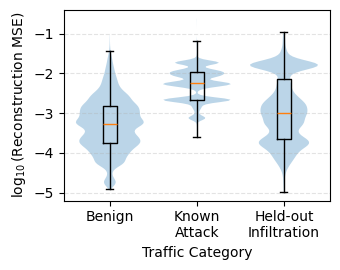


Saved:
/content/drive/MyDrive/CICIDS2018/final_reconstruction_error_figure/fig_reconstruction_error_distribution.png
/content/drive/MyDrive/CICIDS2018/final_reconstruction_error_figure/fig_reconstruction_error_distribution.pdf
/content/drive/MyDrive/CICIDS2018/final_reconstruction_error_figure/reconstruction_error_summary.csv

DONE — frozen model inference only, no retraining.


In [ ]:
# ============================================================
# FINAL RECONSTRUCTION ERROR DISTRIBUTION
# INPUT ONLY:
# 1. model_AE_MLP (1).zip
# 2. dataset_split.joblib
# NO RETRAINING
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import gc
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# ------------------------------------------------------------
# 1. Paths yang memang kamu punya
# ------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/CICIDS2018"

ZIP_PATH = os.path.join(
    BASE_DIR,
    "model_AE_MLP (1).zip"
)

DATASET_PATH = os.path.join(
    BASE_DIR,
    "dataset_split.joblib"
)

EXTRACT_DIR = os.path.join(
    BASE_DIR,
    "temp_extract_ae_mlp"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "final_reconstruction_error_figure"
)

os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"ZIP model tidak ditemukan: {ZIP_PATH}")

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"dataset_split.joblib tidak ditemukan: {DATASET_PATH}"
    )

# ------------------------------------------------------------
# 2. Extract model ZIP
# ------------------------------------------------------------

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

def find_file(root, filename):
    for current_root, _, files in os.walk(root):
        if filename in files:
            return os.path.join(current_root, filename)
    return None

AE_MODEL_PATH = find_file(
    EXTRACT_DIR,
    "ae_model_final.h5"
)

FEATURE_PATH = find_file(
    EXTRACT_DIR,
    "feature_names.pkl"
)

if AE_MODEL_PATH is None:
    raise FileNotFoundError(
        "ae_model_final.h5 tidak ditemukan di dalam ZIP."
    )

print("AE model :", AE_MODEL_PATH)
print("Dataset  :", DATASET_PATH)

# ------------------------------------------------------------
# 3. Load frozen AE lama dan test set
# ------------------------------------------------------------

ae_model = tf.keras.models.load_model(
    AE_MODEL_PATH,
    compile=False
)

data = joblib.load(DATASET_PATH)

X_test = np.asarray(
    data["X_test"],
    dtype=np.float32
)

y_test = np.asarray(
    data["y_test"]
)

label_test = np.char.strip(
    np.asarray(data["label_test"]).astype(str)
)

dataset_features = data.get("features", None)

print("\nX_test shape:", X_test.shape)
print("Input range :", X_test.min(), "to", X_test.max())
print("AE input    :", ae_model.input_shape)

if X_test.shape[1] != ae_model.input_shape[-1]:
    raise ValueError(
        "Jumlah fitur dataset tidak cocok dengan input model."
    )

if FEATURE_PATH is not None and dataset_features is not None:
    model_features = list(joblib.load(FEATURE_PATH))
    dataset_features = list(dataset_features)

    if model_features != dataset_features:
        raise ValueError(
            "Urutan fitur model tidak cocok dengan dataset."
        )

    print("Feature order: MATCH 38/38")

del data
gc.collect()

# ------------------------------------------------------------
# 4. Inference reconstruction error
# Tidak ada fit(), tidak ada training
# ------------------------------------------------------------

CHUNK_SIZE = 100_000
BATCH_SIZE = 4096

reconstruction_error = np.empty(
    len(X_test),
    dtype=np.float32
)

print("\nComputing reconstruction error...")

for start in range(0, len(X_test), CHUNK_SIZE):
    end = min(start + CHUNK_SIZE, len(X_test))

    X_chunk = X_test[start:end]

    X_reconstructed = ae_model.predict(
        X_chunk,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    reconstruction_error[start:end] = np.mean(
        np.square(X_chunk - X_reconstructed),
        axis=1
    ).astype(np.float32)

    print(f"Processed {end:,}/{len(X_test):,}")

    del X_reconstructed
    gc.collect()

# ------------------------------------------------------------
# 5. Bentuk tiga kelompok CICIDS2018
# ------------------------------------------------------------

mask_benign = y_test == 0

mask_infiltration = (
    label_test == "Infiltration"
)

mask_known_attack = (
    (y_test == 1) &
    (~mask_infiltration)
)

err_benign = reconstruction_error[mask_benign]
err_known = reconstruction_error[mask_known_attack]
err_infiltration = reconstruction_error[mask_infiltration]

groups = [
    ("Benign", err_benign),
    ("Known\nAttack", err_known),
    ("Held-out\nInfiltration", err_infiltration),
]

print("\n=== SUPPORT ===")
for name, values in groups:
    print(
        f"{name.replace(chr(10), ' '):<25}: "
        f"{len(values):,}"
    )

# ------------------------------------------------------------
# 6. Statistik memakai semua sampel
# ------------------------------------------------------------

benign_mean = float(np.mean(err_benign))

summary_rows = []

for name, values in groups:
    summary_rows.append({
        "Category": name.replace("\n", " "),
        "Support": int(len(values)),
        "Mean": float(np.mean(values)),
        "Median": float(np.median(values)),
        "P25": float(np.percentile(values, 25)),
        "P75": float(np.percentile(values, 75)),
        "P90": float(np.percentile(values, 90)),
        "P95": float(np.percentile(values, 95)),
        "Mean Ratio to Benign": float(
            np.mean(values) / benign_mean
        )
    })

summary = pd.DataFrame(summary_rows)

for column in [
    "Mean",
    "Median",
    "P25",
    "P75",
    "P90",
    "P95",
    "Mean Ratio to Benign"
]:
    summary[column] = summary[column].round(6)

summary_path = os.path.join(
    OUTPUT_DIR,
    "reconstruction_error_summary.csv"
)

summary.to_csv(summary_path, index=False)

print("\n=== RECONSTRUCTION ERROR SUMMARY ===")
print(summary.to_string(index=False))

# ------------------------------------------------------------
# 7. Sampel seimbang hanya untuk menggambar violin
# Statistik di atas tetap menggunakan seluruh data
# ------------------------------------------------------------

EPS = 1e-12
PLOT_SAMPLE_PER_GROUP = 20_000
RANDOM_STATE = 42

def sample_for_visualization(values, n, seed):
    values = np.asarray(values)

    if len(values) <= n:
        return values

    rng = np.random.default_rng(seed)

    indices = rng.choice(
        len(values),
        size=n,
        replace=False
    )

    return values[indices]

plot_data = []

for index, (_, values) in enumerate(groups):
    sampled = sample_for_visualization(
        values,
        PLOT_SAMPLE_PER_GROUP,
        RANDOM_STATE + index
    )

    plot_data.append(
        np.log10(sampled + EPS)
    )

# ------------------------------------------------------------
# 8. Figure final ukuran satu kolom IEEE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(3.5, 2.8)
)

positions = [1, 2, 3]

ax.violinplot(
    plot_data,
    positions=positions,
    widths=0.78,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

ax.boxplot(
    plot_data,
    positions=positions,
    widths=0.16,
    showfliers=False,
    manage_ticks=False
)

ax.set_xticks(positions)

ax.set_xticklabels([
    "Benign",
    "Known\nAttack",
    "Held-out\nInfiltration"
])

ax.set_ylabel(
    r"$\log_{10}$(Reconstruction MSE)"
)

ax.set_xlabel(
    "Traffic Category"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

fig.tight_layout()

png_path = os.path.join(
    OUTPUT_DIR,
    "fig_reconstruction_error_distribution.png"
)

pdf_path = os.path.join(
    OUTPUT_DIR,
    "fig_reconstruction_error_distribution.pdf"
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(png_path)
print(pdf_path)
print(summary_path)

print("\nDONE — frozen model inference only, no retraining.")

In [ ]:
# ============================================================
# COUNT-MATCH DATASET TEST SET TO OLD NOTEBOOK DISTRIBUTION
#
# IMPORTANT:
# - Menyamakan JUMLAH label dengan notebook lama.
# - BUKAN mengembalikan sampel asli yang hilang.
# - Empat kelas attack ditambah melalui deterministic duplication.
# - Empat sampel Benign dikurangi.
# - Simpan sebagai file BARU, jangan mengaku sebagai split asli lama.
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import gc
import joblib
import numpy as np
import pandas as pd
from datetime import datetime

# ------------------------------------------------------------
# 1. Source dan output
# ------------------------------------------------------------

SOURCE_PATH = (
    "/content/drive/MyDrive/CICIDS2018/"
    "dataset_split.joblib"
)

OUTPUT_PATH = (
    "/content/drive/MyDrive/CICIDS2018/"
    "dataset_split_count_matched_old_distribution.joblib"
)

AUDIT_PATH = (
    "/content/drive/MyDrive/CICIDS2018/"
    "dataset_split_count_matched_old_distribution_audit.csv"
)

RANDOM_STATE = 42

if not os.path.exists(SOURCE_PATH):
    raise FileNotFoundError(
        f"Dataset tidak ditemukan:\n{SOURCE_PATH}"
    )

# ------------------------------------------------------------
# 2. Target jumlah test dari notebook lama
# ------------------------------------------------------------

TARGET_TEST_COUNTS = {
    "Benign": 1_347_722,
    "DDOS attack-HOIC": 102_902,
    "DDoS attacks-LOIC-HTTP": 86_428,
    "DoS attacks-Hulk": 69_287,
    "Bot": 42_928,
    "FTP-BruteForce": 29_004,
    "SSH-Bruteforce": 28_139,
    "Infiltration": 24_180,
    "DoS attacks-SlowHTTPTest": 20_983,
    "DoS attacks-GoldenEye": 6_227,
    "DoS attacks-Slowloris": 1_648,
    "DDOS attack-LOIC-UDP": 260,
    "Brute Force -Web": 92,
    "Brute Force -XSS": 35,
    "SQL Injection": 13,
}

# ------------------------------------------------------------
# 3. Load dataset
# ------------------------------------------------------------

print("Loading dataset...")
data = joblib.load(SOURCE_PATH)

X_test = np.asarray(data["X_test"])
y_test = np.asarray(data["y_test"])
label_test = np.char.strip(
    np.asarray(data["label_test"]).astype(str)
)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("label_test:", label_test.shape)

if not (
    len(X_test) == len(y_test) == len(label_test)
):
    raise ValueError(
        "Panjang X_test, y_test, dan label_test tidak sama."
    )

# ------------------------------------------------------------
# 4. Audit distribusi awal
# ------------------------------------------------------------

current_counts = (
    pd.Series(label_test)
    .value_counts()
    .to_dict()
)

audit_rows = []

all_labels = sorted(
    set(TARGET_TEST_COUNTS) |
    set(current_counts)
)

for label in all_labels:
    current = int(current_counts.get(label, 0))
    target = int(TARGET_TEST_COUNTS.get(label, 0))

    audit_rows.append({
        "Label": label,
        "Current": current,
        "Target Old Notebook": target,
        "Difference Needed": target - current
    })

df_before = pd.DataFrame(audit_rows)

print("\n=== BEFORE COUNT MATCHING ===")
print(df_before.to_string(index=False))

unknown_labels = (
    set(current_counts) -
    set(TARGET_TEST_COUNTS)
)

if unknown_labels:
    raise ValueError(
        "Dataset memiliki label yang tidak ada dalam target:\n"
        + ", ".join(sorted(unknown_labels))
    )

# ------------------------------------------------------------
# 5. Tentukan baris yang harus dihapus dan diduplikasi
# ------------------------------------------------------------

rng = np.random.default_rng(RANDOM_STATE)

remove_indices = []
duplicate_indices = []
operation_log = []

for label, target_count in TARGET_TEST_COUNTS.items():
    indices = np.where(label_test == label)[0]
    current_count = len(indices)
    difference = target_count - current_count

    if difference < 0:
        # Terlalu banyak: hapus secara deterministik
        n_remove = abs(difference)

        selected_remove = rng.choice(
            indices,
            size=n_remove,
            replace=False
        )

        remove_indices.extend(
            selected_remove.tolist()
        )

        operation_log.append({
            "Label": label,
            "Operation": "Remove",
            "Number": n_remove,
            "Source indices": ",".join(
                map(str, selected_remove.tolist())
            )
        })

    elif difference > 0:
        # Kurang: duplikasi sampel yang sudah ada
        # Ini bukan pemulihan sampel asli.
        selected_duplicate = rng.choice(
            indices,
            size=difference,
            replace=(difference > len(indices))
        )

        duplicate_indices.extend(
            selected_duplicate.tolist()
        )

        operation_log.append({
            "Label": label,
            "Operation": "Duplicate",
            "Number": difference,
            "Source indices": ",".join(
                map(str, selected_duplicate.tolist())
            )
        })

# ------------------------------------------------------------
# 6. Bentuk test set count-matched
# ------------------------------------------------------------

remove_indices = np.asarray(
    sorted(set(remove_indices)),
    dtype=np.int64
)

duplicate_indices = np.asarray(
    duplicate_indices,
    dtype=np.int64
)

keep_mask = np.ones(
    len(X_test),
    dtype=bool
)

keep_mask[remove_indices] = False

X_kept = X_test[keep_mask]
y_kept = y_test[keep_mask]
labels_kept = label_test[keep_mask]

if len(duplicate_indices) > 0:
    X_test_matched = np.concatenate(
        [
            X_kept,
            X_test[duplicate_indices]
        ],
        axis=0
    )

    y_test_matched = np.concatenate(
        [
            y_kept,
            y_test[duplicate_indices]
        ],
        axis=0
    )

    label_test_matched = np.concatenate(
        [
            labels_kept,
            label_test[duplicate_indices]
        ],
        axis=0
    )
else:
    X_test_matched = X_kept
    y_test_matched = y_kept
    label_test_matched = labels_kept

print("\nRemoved rows   :", len(remove_indices))
print("Duplicated rows:", len(duplicate_indices))
print("Final test size:", len(X_test_matched))

# ------------------------------------------------------------
# 7. Audit hasil
# ------------------------------------------------------------

final_counts = (
    pd.Series(label_test_matched)
    .value_counts()
    .to_dict()
)

final_audit_rows = []

for label, target in TARGET_TEST_COUNTS.items():
    actual = int(final_counts.get(label, 0))

    final_audit_rows.append({
        "Label": label,
        "Target Old Notebook": target,
        "Count-Matched Actual": actual,
        "Difference": actual - target,
        "Status": (
            "MATCH"
            if actual == target
            else "NOT MATCH"
        )
    })

df_after = pd.DataFrame(
    final_audit_rows
).sort_values(
    "Target Old Notebook",
    ascending=False
)

print("\n=== AFTER COUNT MATCHING ===")
print(df_after.to_string(index=False))

if not (df_after["Status"] == "MATCH").all():
    raise RuntimeError(
        "Jumlah label belum seluruhnya cocok."
    )

if len(X_test_matched) != 1_759_848:
    raise RuntimeError(
        "Total test set tidak sama dengan 1,759,848."
    )

binary_benign = int(
    np.sum(y_test_matched == 0)
)

binary_attack = int(
    np.sum(y_test_matched == 1)
)

print("\n=== FINAL BINARY COUNTS ===")
print("Benign:", f"{binary_benign:,}")
print("Attack:", f"{binary_attack:,}")
print("Total :", f"{len(y_test_matched):,}")

if binary_benign != 1_347_722:
    raise RuntimeError(
        "Binary Benign tidak cocok."
    )

if binary_attack != 412_126:
    raise RuntimeError(
        "Binary Attack tidak cocok."
    )

# ------------------------------------------------------------
# 8. Simpan sebagai file BARU
# ------------------------------------------------------------

data["X_test"] = X_test_matched.astype(
    X_test.dtype,
    copy=False
)

data["y_test"] = y_test_matched.astype(
    y_test.dtype,
    copy=False
)

data["label_test"] = label_test_matched

data["count_match_metadata"] = {
    "source_dataset": SOURCE_PATH,
    "created_at": datetime.now().isoformat(),
    "random_state": RANDOM_STATE,
    "purpose": (
        "Count-matched reconstruction of the old notebook "
        "test-label distribution"
    ),
    "warning": (
        "This is not the original historical split. "
        "Four attack samples were deterministically duplicated "
        "and four Benign samples were removed."
    ),
    "removed_original_indices": remove_indices.tolist(),
    "duplicated_source_indices": duplicate_indices.tolist(),
    "operations": operation_log,
}

print("\nSaving reconstructed count-matched dataset...")

joblib.dump(
    data,
    OUTPUT_PATH,
    compress=3
)

df_after.to_csv(
    AUDIT_PATH,
    index=False
)

print("\nSaved:")
print(OUTPUT_PATH)
print(AUDIT_PATH)

print("\nIMPORTANT:")
print(
    "Jumlah label sudah sama dengan notebook lama, "
    "tetapi ini bukan split asli lama yang identik."
)

# Bersihkan memori
del data
del X_test, y_test, label_test
del X_kept, y_kept, labels_kept
del X_test_matched, y_test_matched, label_test_matched
gc.collect()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset...
X_test: (1759848, 38)
y_test: (1759848,)
label_test: (1759848,)

=== BEFORE COUNT MATCHING ===
                   Label  Current  Target Old Notebook  Difference Needed
                  Benign  1347726              1347722                 -4
                     Bot    42928                42928                  0
        Brute Force -Web       92                   92                  0
        Brute Force -XSS       35                   35                  0
        DDOS attack-HOIC   102902               102902                  0
    DDOS attack-LOIC-UDP      260                  260                  0
  DDoS attacks-LOIC-HTTP    86428                86428                  0
   DoS attacks-GoldenEye     6227                 6227                  0
        DoS attacks-Hulk    69286                69287                  1
DoS attacks-SlowH

3469

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AE model : /content/drive/MyDrive/CICIDS2018/extracted_model_AE_MLP_ieee/ae_model_final.h5
Dataset  : /content/drive/MyDrive/CICIDS2018/dataset_split_count_matched_old_distribution.joblib

=== AUTOENCODER ===
Input shape : (None, 38)
Output shape: (None, 38)

Loading test set...

=== TEST SET ===
X_test shape : (1759848, 38)
y_test shape : (1759848,)
Label shape  : (1759848,)
Input range  : 0.0 to 1.0
Feature order : MATCH 38/38

=== TEST LABEL AUDIT ===
                   Label  Expected  Actual Status
                  Benign   1347722 1347722  MATCH
        DDOS attack-HOIC    102902  102902  MATCH
  DDoS attacks-LOIC-HTTP     86428   86428  MATCH
        DoS attacks-Hulk     69287   69287  MATCH
                     Bot     42928   42928  MATCH
          FTP-BruteForce     29004   29004  MATCH
          SSH-Bruteforce     28139   28139  MATCH
            

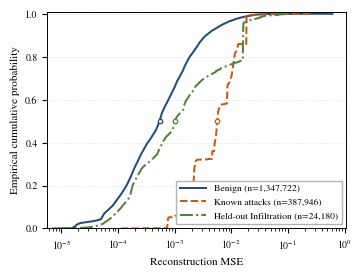


=== SAVED OUTPUTS ===
PDF figure : /content/drive/MyDrive/CICIDS2018/reconstruction_error_ieee/fig_reconstruction_error_ecdf_ieee.pdf
PNG figure : /content/drive/MyDrive/CICIDS2018/reconstruction_error_ieee/fig_reconstruction_error_ecdf_ieee.png
Summary    : /content/drive/MyDrive/CICIDS2018/reconstruction_error_ieee/reconstruction_error_summary.csv
Raw errors : /content/drive/MyDrive/CICIDS2018/reconstruction_error_ieee/cicids2018_reconstruction_error_full_test.npz

DONE — frozen AE inference only; no retraining and no rescaling.


In [ ]:
# ============================================================
# IEEE-READY RECONSTRUCTION ERROR DISTRIBUTION
# Figure type : ECDF with logarithmic x-axis
# Model       : Frozen Autoencoder
# Dataset     : Count-matched shared CSE-CIC-IDS2018 test set
# Training    : NONE
# Rescaling   : NONE — X_test is already scaled
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import gc
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# ============================================================
# 1. PATH CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/CICIDS2018"

MODEL_ZIP_PATH = os.path.join(
    BASE_DIR,
    "model_AE_MLP (1).zip"
)

DATASET_PATH = os.path.join(
    BASE_DIR,
    "dataset_split_count_matched_old_distribution.joblib"
)

EXTRACT_DIR = os.path.join(
    BASE_DIR,
    "extracted_model_AE_MLP_ieee"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "reconstruction_error_ieee"
)

os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Output files
RAW_ERROR_PATH = os.path.join(
    OUTPUT_DIR,
    "cicids2018_reconstruction_error_full_test.npz"
)

SUMMARY_PATH = os.path.join(
    OUTPUT_DIR,
    "reconstruction_error_summary.csv"
)

FIGURE_PDF_PATH = os.path.join(
    OUTPUT_DIR,
    "fig_reconstruction_error_ecdf_ieee.pdf"
)

FIGURE_PNG_PATH = os.path.join(
    OUTPUT_DIR,
    "fig_reconstruction_error_ecdf_ieee.png"
)

# ============================================================
# 2. FILE VALIDATION AND MODEL EXTRACTION
# ============================================================

if not os.path.exists(MODEL_ZIP_PATH):
    raise FileNotFoundError(
        f"Model ZIP tidak ditemukan:\n{MODEL_ZIP_PATH}"
    )

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset tidak ditemukan:\n{DATASET_PATH}"
    )

with zipfile.ZipFile(MODEL_ZIP_PATH, "r") as zip_file:
    zip_file.extractall(EXTRACT_DIR)

def find_file(root_directory, filename):
    for current_root, _, files in os.walk(root_directory):
        if filename in files:
            return os.path.join(current_root, filename)
    return None

AE_MODEL_PATH = find_file(
    EXTRACT_DIR,
    "ae_model_final.h5"
)

FEATURE_NAMES_PATH = find_file(
    EXTRACT_DIR,
    "feature_names.pkl"
)

if AE_MODEL_PATH is None:
    raise FileNotFoundError(
        "ae_model_final.h5 tidak ditemukan di dalam ZIP model."
    )

print("AE model :", AE_MODEL_PATH)
print("Dataset  :", DATASET_PATH)

# ============================================================
# 3. LOAD FROZEN AUTOENCODER
# ============================================================

tf.keras.backend.clear_session()

ae_model = tf.keras.models.load_model(
    AE_MODEL_PATH,
    compile=False
)

print("\n=== AUTOENCODER ===")
print("Input shape :", ae_model.input_shape)
print("Output shape:", ae_model.output_shape)

if ae_model.input_shape[-1] != 38:
    raise ValueError(
        "Autoencoder tidak memiliki input 38 fitur."
    )

if ae_model.output_shape[-1] != 38:
    raise ValueError(
        "Output autoencoder tidak memiliki 38 fitur."
    )

# ============================================================
# 4. LOAD SHARED TEST SET
# ============================================================

print("\nLoading test set...")

dataset = joblib.load(DATASET_PATH)

required_keys = [
    "X_test",
    "y_test",
    "label_test",
    "features"
]

missing_keys = [
    key for key in required_keys
    if key not in dataset
]

if missing_keys:
    raise KeyError(
        f"Key dataset tidak lengkap: {missing_keys}"
    )

X_test = np.asarray(
    dataset["X_test"],
    dtype=np.float32
)

y_test = np.asarray(
    dataset["y_test"]
).reshape(-1)

label_test = np.char.strip(
    np.asarray(dataset["label_test"]).astype(str)
)

dataset_features = list(
    dataset["features"]
)

# Dataset object tidak dibutuhkan lagi
del dataset
gc.collect()

print("\n=== TEST SET ===")
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Label shape  :", label_test.shape)
print("Input range  :", float(X_test.min()), "to", float(X_test.max()))

if X_test.shape != (1_759_848, 38):
    raise ValueError(
        f"Shape test set tidak sesuai: {X_test.shape}"
    )

if not (
    len(X_test) == len(y_test) == len(label_test)
):
    raise ValueError(
        "Jumlah X_test, y_test, dan label_test tidak sama."
    )

# X_test sudah melalui QuantileTransformer pada preprocessing.
# Jangan menggunakan scaler lagi.
if X_test.min() < -1e-6 or X_test.max() > 1.000001:
    raise ValueError(
        "Range X_test tidak sesuai dengan hasil scaling [0,1]."
    )

# ============================================================
# 5. FEATURE-ORDER VERIFICATION
# ============================================================

if FEATURE_NAMES_PATH is not None:
    model_features = list(
        joblib.load(FEATURE_NAMES_PATH)
    )

    if model_features != dataset_features:
        print("\nDataset features:")
        print(dataset_features)

        print("\nModel features:")
        print(model_features)

        raise ValueError(
            "Urutan fitur dataset tidak cocok dengan model."
        )

    print("Feature order : MATCH 38/38")
else:
    print(
        "Peringatan: feature_names.pkl tidak ditemukan. "
        "Pemeriksaan hanya berdasarkan dimensi input."
    )

# ============================================================
# 6. VERIFY COUNT-MATCHED TEST DISTRIBUTION
# ============================================================

EXPECTED_COUNTS = {
    "Benign": 1_347_722,
    "DDOS attack-HOIC": 102_902,
    "DDoS attacks-LOIC-HTTP": 86_428,
    "DoS attacks-Hulk": 69_287,
    "Bot": 42_928,
    "FTP-BruteForce": 29_004,
    "SSH-Bruteforce": 28_139,
    "Infiltration": 24_180,
    "DoS attacks-SlowHTTPTest": 20_983,
    "DoS attacks-GoldenEye": 6_227,
    "DoS attacks-Slowloris": 1_648,
    "DDOS attack-LOIC-UDP": 260,
    "Brute Force -Web": 92,
    "Brute Force -XSS": 35,
    "SQL Injection": 13,
}

actual_distribution = (
    pd.Series(label_test)
    .value_counts()
    .to_dict()
)

distribution_rows = []

for label, expected in EXPECTED_COUNTS.items():
    actual = int(
        actual_distribution.get(label, 0)
    )

    distribution_rows.append({
        "Label": label,
        "Expected": expected,
        "Actual": actual,
        "Status": (
            "MATCH"
            if expected == actual
            else "NOT MATCH"
        )
    })

distribution_audit = pd.DataFrame(
    distribution_rows
)

print("\n=== TEST LABEL AUDIT ===")
print(distribution_audit.to_string(index=False))

if not (
    distribution_audit["Status"] == "MATCH"
).all():
    raise RuntimeError(
        "Distribusi test set tidak sesuai target."
    )

# Binary-label consistency
benign_from_binary = y_test == 0
benign_from_label = label_test == "Benign"

mismatch_count = int(
    np.sum(
        benign_from_binary != benign_from_label
    )
)

print("\nBinary-label mismatches:", mismatch_count)

if mismatch_count != 0:
    raise RuntimeError(
        "Ditemukan ketidaksesuaian antara y_test dan label_test."
    )

# ============================================================
# 7. COMPUTE RECONSTRUCTION ERROR
# ============================================================
# MSE_i = mean((x_i - x_hat_i)^2)
#
# Tidak ada training.
# Tidak ada scaling ulang.
# Tidak menggunakan classifier threshold 0.72.

CHUNK_SIZE = 100_000
BATCH_SIZE = 4096

reconstruction_error = np.empty(
    len(X_test),
    dtype=np.float32
)

print("\n=== COMPUTING RECONSTRUCTION ERROR ===")

for start_index in range(
    0,
    len(X_test),
    CHUNK_SIZE
):
    end_index = min(
        start_index + CHUNK_SIZE,
        len(X_test)
    )

    X_chunk = X_test[
        start_index:end_index
    ]

    reconstructed_chunk = ae_model.predict(
        X_chunk,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    reconstruction_error[
        start_index:end_index
    ] = np.mean(
        np.square(
            X_chunk - reconstructed_chunk
        ),
        axis=1
    ).astype(np.float32)

    print(
        f"Processed "
        f"{end_index:,}/{len(X_test):,}"
    )

    del reconstructed_chunk
    gc.collect()

if not np.isfinite(reconstruction_error).all():
    raise RuntimeError(
        "Reconstruction error mengandung NaN atau Inf."
    )

print("\nReconstruction error completed.")
print("Minimum:", float(reconstruction_error.min()))
print("Maximum:", float(reconstruction_error.max()))

# ============================================================
# 8. CREATE THREE ANALYSIS GROUPS
# ============================================================

mask_benign = y_test == 0

mask_infiltration = (
    label_test == "Infiltration"
)

mask_known_attack = (
    (y_test == 1) &
    (~mask_infiltration)
)

err_benign = reconstruction_error[
    mask_benign
]

err_known_attack = reconstruction_error[
    mask_known_attack
]

err_infiltration = reconstruction_error[
    mask_infiltration
]

groups = [
    ("Benign", err_benign),
    ("Known attacks", err_known_attack),
    ("Held-out Infiltration", err_infiltration),
]

print("\n=== GROUP SUPPORT ===")

for group_name, group_values in groups:
    print(
        f"{group_name:<25}: "
        f"{len(group_values):,}"
    )

assert len(err_benign) == 1_347_722
assert len(err_known_attack) == 387_946
assert len(err_infiltration) == 24_180

# ============================================================
# 9. FULL-DATA DESCRIPTIVE STATISTICS
# ============================================================

benign_mean = float(
    np.mean(err_benign)
)

summary_rows = []

for group_name, values in groups:
    values = np.asarray(
        values,
        dtype=np.float64
    )

    summary_rows.append({
        "Traffic category": group_name,
        "Support": len(values),
        "Mean MSE": np.mean(values),
        "Median MSE": np.median(values),
        "Standard deviation": np.std(values),
        "P25": np.percentile(values, 25),
        "P75": np.percentile(values, 75),
        "P90": np.percentile(values, 90),
        "P95": np.percentile(values, 95),
        "P99": np.percentile(values, 99),
        "Mean ratio to Benign": (
            np.mean(values) / benign_mean
        )
    })

summary_df = pd.DataFrame(
    summary_rows
)

summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)

print("\n=== RECONSTRUCTION ERROR SUMMARY ===")
print(
    summary_df.to_string(
        index=False,
        formatters={
            "Mean MSE": lambda x: f"{x:.8f}",
            "Median MSE": lambda x: f"{x:.8f}",
            "Standard deviation": lambda x: f"{x:.8f}",
            "P25": lambda x: f"{x:.8f}",
            "P75": lambda x: f"{x:.8f}",
            "P90": lambda x: f"{x:.8f}",
            "P95": lambda x: f"{x:.8f}",
            "P99": lambda x: f"{x:.8f}",
            "Mean ratio to Benign": lambda x: f"{x:.3f}"
        }
    )
)

# ============================================================
# 10. SAVE RAW EVIDENCE
# ============================================================

np.savez_compressed(
    RAW_ERROR_PATH,
    reconstruction_error=reconstruction_error,
    y_test=y_test.astype(np.int8),
    label_test=label_test
)

print("\nRaw evidence saved:")
print(RAW_ERROR_PATH)

# ============================================================
# 11. PREPARE LIGHTWEIGHT FULL-DATA ECDF
# ============================================================
# ECDF is evaluated at 4,000 probability levels.
# Quantiles are calculated from the complete group arrays.
# This keeps the vector PDF small without random sampling.

N_ECDF_POINTS = 4000
EPSILON = 1e-12

probability_levels = np.linspace(
    0.0,
    1.0,
    N_ECDF_POINTS
)

ecdf_curves = []

for group_name, values in groups:
    clipped_values = np.clip(
        np.asarray(values, dtype=np.float64),
        EPSILON,
        None
    )

    quantile_values = np.quantile(
        clipped_values,
        probability_levels
    )

    ecdf_curves.append(
        (
            group_name,
            quantile_values,
            probability_levels
        )
    )

# ============================================================
# 12. IEEE FIGURE CONFIGURATION
# ============================================================

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.8,
    "axes.linewidth": 0.7,
    "lines.linewidth": 1.4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.facecolor": "white",
    "figure.facecolor": "white"
})

# IEEE single-column width ≈ 3.5 inches
fig, ax = plt.subplots(
    figsize=(3.50, 2.65)
)

line_styles = [
    "-",
    "--",
    "-."
]

line_colors = [
    "#1F4E79",
    "#C55A11",
    "#548235"
]

support_values = {
    "Benign": len(err_benign),
    "Known attacks": len(err_known_attack),
    "Held-out Infiltration": len(err_infiltration),
}

for (
    group_name,
    x_values,
    y_values
), line_style, line_color in zip(
    ecdf_curves,
    line_styles,
    line_colors
):
    ax.plot(
        x_values,
        y_values,
        linestyle=line_style,
        color=line_color,
        linewidth=1.45,
        label=(
            f"{group_name} "
            f"(n={support_values[group_name]:,})"
        )
    )

# Logarithmic x-axis keeps the original MSE unit
ax.set_xscale("log")

ax.set_xlabel(
    "Reconstruction MSE"
)

ax.set_ylabel(
    "Empirical cumulative probability"
)

ax.set_xlim(
    left=max(
        EPSILON,
        min(
            curve[1][0]
            for curve in ecdf_curves
        ) * 0.8
    )
)

ax.set_ylim(
    0.0,
    1.01
)

ax.set_yticks(
    np.arange(
        0.0,
        1.01,
        0.2
    )
)

# Median markers: ECDF probability = 0.5
for (
    group_name,
    x_values,
    y_values
), line_color in zip(
    ecdf_curves,
    line_colors
):
    median_index = np.searchsorted(
        y_values,
        0.5
    )

    median_x = x_values[
        min(
            median_index,
            len(x_values) - 1
        )
    ]

    ax.plot(
        median_x,
        0.5,
        marker="o",
        markersize=3.2,
        markerfacecolor="white",
        markeredgecolor=line_color,
        markeredgewidth=0.9,
        linestyle="None"
    )

ax.grid(
    axis="y",
    linestyle=":",
    linewidth=0.5,
    alpha=0.55
)

ax.legend(
    loc="lower right",
    frameon=True,
    framealpha=1.0,
    edgecolor="0.7",
    fancybox=False,
    handlelength=2.8
)

# IEEE figures generally do not use a title inside the plot
fig.tight_layout(
    pad=0.35
)

# Vector PDF
fig.savefig(
    FIGURE_PDF_PATH,
    format="pdf",
    bbox_inches="tight"
)

# High-resolution PNG
fig.savefig(
    FIGURE_PNG_PATH,
    format="png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n=== SAVED OUTPUTS ===")
print("PDF figure :", FIGURE_PDF_PATH)
print("PNG figure :", FIGURE_PNG_PATH)
print("Summary    :", SUMMARY_PATH)
print("Raw errors :", RAW_ERROR_PATH)

print(
    "\nDONE — frozen AE inference only; "
    "no retraining and no rescaling."
)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Google Drive sudah mounted di /content/drive

# Tidak perlu menjalankan drive.mount() lagi.

OUTPUT_DIR = (
"/content/drive/MyDrive/CICIDS2018/"
"revision_confusion_matrix"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

PDF_PATH = os.path.join(
OUTPUT_DIR,
"fig_comparative_confusion_matrices_ieee.pdf"
)

PNG_PATH = os.path.join(
OUTPUT_DIR,
"fig_comparative_confusion_matrices_ieee.png"
)

CSV_PATH = os.path.join(
OUTPUT_DIR,
"comparative_confusion_matrix_metrics.csv"
)

OUTPUT_DIR = (
"/content/drive/MyDrive/CICIDS2018/"
"revision_confusion_matrix"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

PDF_PATH = os.path.join(
OUTPUT_DIR,
"fig_comparative_confusion_matrices_ieee.pdf"
)

PNG_PATH = os.path.join(
OUTPUT_DIR,
"fig_comparative_confusion_matrices_ieee.png"
)

CSV_PATH = os.path.join(
OUTPUT_DIR,
"comparative_confusion_matrix_metrics.csv"
)

# ============================================================

# 3. Confusion matrix dari output notebook eksperimen asli

#

# Format:

# [[TN, FP],

# [FN, TP]]

# ============================================================

confusion_matrices = {
"AE-MLP": np.array([
[1_344_768, 2_954],
[23_249, 388_877]
], dtype=np.int64),

```
"MLP": np.array([
    [1_347_470, 252],
    [24_689, 387_437]
], dtype=np.int64),

"LightGBM": np.array([
    [1_347_567, 155],
    [24_315, 387_811]
], dtype=np.int64)
```

}

thresholds = {
"AE-MLP": 0.72,
"MLP": 0.87,
"LightGBM": 0.68
}

MODEL_ORDER = [
"AE-MLP",
"MLP",
"LightGBM"
]

EXPECTED_BENIGN = 1_347_722
EXPECTED_ATTACK = 412_126
EXPECTED_TOTAL = 1_759_848

# ============================================================

# 4. Validasi jumlah test set

# ============================================================

print("=== CONFUSION-MATRIX AUDIT ===")

for model_name in MODEL_ORDER:
matrix = confusion_matrices[model_name]

```
benign_support = int(matrix[0].sum())
attack_support = int(matrix[1].sum())
total_support = int(matrix.sum())

print(f"\n{model_name}")
print(matrix)
print("Benign support :", f"{benign_support:,}")
print("Attack support :", f"{attack_support:,}")
print("Total support  :", f"{total_support:,}")

if benign_support != EXPECTED_BENIGN:
    raise ValueError(
        f"Jumlah Benign {model_name} tidak sesuai."
    )

if attack_support != EXPECTED_ATTACK:
    raise ValueError(
        f"Jumlah Attack {model_name} tidak sesuai."
    )

if total_support != EXPECTED_TOTAL:
    raise ValueError(
        f"Total test {model_name} tidak sesuai."
    )
```

print("\nSemua model menggunakan support yang sama.")

# ============================================================

# 5. Hitung metrik dari confusion matrix

# ============================================================

metric_rows = []

for model_name in MODEL_ORDER:
matrix = confusion_matrices[model_name]

```
tn, fp, fn, tp = matrix.ravel()

accuracy = (
    (tp + tn) /
    (tp + tn + fp + fn)
)

precision = (
    tp / (tp + fp)
    if (tp + fp) > 0
    else np.nan
)

recall = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else np.nan
)

f1_score = (
    2 * precision * recall /
    (precision + recall)
    if (precision + recall) > 0
    else np.nan
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else np.nan
)

fpr = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else np.nan
)

fnr = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else np.nan
)

metric_rows.append({
    "Model": model_name,
    "Threshold": thresholds[model_name],
    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),
    "Accuracy": accuracy,
    "Precision_Attack": precision,
    "Recall_Attack": recall,
    "F1_Attack": f1_score,
    "Specificity": specificity,
    "FPR": fpr,
    "FNR": fnr
})
```

metrics_df = pd.DataFrame(metric_rows)

metrics_df.to_csv(
CSV_PATH,
index=False
)

print("\n=== COMPARATIVE METRICS ===")

display_df = metrics_df.copy()

percentage_columns = [
"Accuracy",
"Precision_Attack",
"Recall_Attack",
"F1_Attack",
"Specificity",
"FPR",
"FNR"
]

for column in percentage_columns:
display_df[column] = (
display_df[column] * 100
)

print(
display_df.to_string(
index=False,
formatters={
"Threshold": lambda x: f"{x:.2f}",
"Accuracy": lambda x: f"{x:.4f}%",
"Precision_Attack": lambda x: f"{x:.4f}%",
"Recall_Attack": lambda x: f"{x:.4f}%",
"F1_Attack": lambda x: f"{x:.4f}%",
"Specificity": lambda x: f"{x:.4f}%",
"FPR": lambda x: f"{x:.4f}%",
"FNR": lambda x: f"{x:.4f}%"
}
)
)

# ============================================================

# 6. IEEE figure style

# ============================================================

plt.rcParams.update({
"font.family": "STIXGeneral",
"mathtext.fontset": "stix",
"font.size": 8,
"axes.titlesize": 8.5,
"axes.labelsize": 8,
"xtick.labelsize": 7.5,
"ytick.labelsize": 7.5,
"axes.linewidth": 0.7,
"pdf.fonttype": 42,
"ps.fonttype": 42,
"figure.facecolor": "white",
"savefig.facecolor": "white"
})

# IEEE double-column width

fig, axes = plt.subplots(
1,
3,
figsize=(7.16, 2.35),
constrained_layout=True
)

class_names = [
"Benign",
"Attack"
]

last_image = None

for panel_index, model_name in enumerate(
MODEL_ORDER
):
axis = axes[panel_index]

```
matrix = confusion_matrices[
    model_name
]

row_totals = matrix.sum(
    axis=1,
    keepdims=True
)

normalized_matrix = (
    matrix / row_totals
)

last_image = axis.imshow(
    normalized_matrix * 100,
    cmap="Blues",
    vmin=0,
    vmax=100,
    aspect="equal"
)

for actual_index in range(2):
    for predicted_index in range(2):
        count = matrix[
            actual_index,
            predicted_index
        ]

        percentage = (
            normalized_matrix[
                actual_index,
                predicted_index
            ] * 100
        )

        text_color = (
            "white"
            if percentage >= 50
            else "black"
        )

        axis.text(
            predicted_index,
            actual_index,
            f"{count:,}\n{percentage:.2f}%",
            ha="center",
            va="center",
            fontsize=7.2,
            color=text_color,
            linespacing=1.15
        )

axis.set_xticks(
    [0, 1],
    labels=class_names
)

axis.set_yticks(
    [0, 1],
    labels=class_names
)

axis.set_xlabel(
    "Predicted class"
)

if panel_index == 0:
    axis.set_ylabel(
        "Actual class"
    )

panel_letter = chr(
    ord("a") + panel_index
)

axis.set_title(
    f"({panel_letter}) {model_name} "
    f"($\\tau$={thresholds[model_name]:.2f})",
    pad=4
)

axis.set_xticks(
    np.arange(-0.5, 2, 1),
    minor=True
)

axis.set_yticks(
    np.arange(-0.5, 2, 1),
    minor=True
)

axis.grid(
    which="minor",
    color="white",
    linewidth=1.1
)

axis.tick_params(
    which="minor",
    bottom=False,
    left=False
)
```

colorbar = fig.colorbar(
last_image,
ax=axes.ravel().tolist(),
fraction=0.025,
pad=0.02
)

colorbar.set_label(
"Row-normalized proportion (%)",
fontsize=7.5
)

colorbar.ax.tick_params(
labelsize=7
)

# ============================================================

# 7. Simpan output

# ============================================================

fig.savefig(
PDF_PATH,
format="pdf",
bbox_inches="tight"
)

fig.savefig(
PNG_PATH,
format="png",
dpi=600,
bbox_inches="tight"
)

plt.show()

print("\n=== SAVED OUTPUTS ===")
print("PDF :", PDF_PATH)
print("PNG :", PNG_PATH)
print("CSV :", CSV_PATH)


SyntaxError: invalid syntax (2493376038.py, line 74)